# DeepLOB + DLS Asset Allocation — Kaggle Edition

This notebook combines the **Shifu DeepLOB out-of-sample pipeline** with the **DLS portfolio optimizer** and is configured to run directly in a Kaggle Notebook.

```text
Kaggle input datasets under /kaggle/input
→ in-sample and release/OOS OHLCV + LOB parquet files
→ pretrained DeepLOB checkpoint: best_model_alpha_0015.pt
→ DeepLOB probability features
→ DLS LSTM + Softmax portfolio optimizer
→ target portfolio weights
→ open/VWAP execution engine
→ OOS metrics, audit tables, charts, submission CSV, and downloadable ZIP
```

## Kaggle setup

Before running the notebook:

1. Open **Add Input** and attach the public dataset `arshiaabolghasemi/feishu-dataset`.
2. Attach another Kaggle dataset containing `best_model_alpha_0015.pt`. A private dataset is acceptable.
3. In **Notebook options**, select a GPU accelerator such as **T4 x2**, **T4**, or **P100** when available.
4. Use **Run All**. Internet access is not required after both inputs are attached.

The notebook recursively searches `/kaggle/input` for all required files, so the checkpoint dataset can have any Kaggle dataset name.

Required filenames:

```text
daily_data_in_sample.parquet
lob_data_in_sample.parquet
daily_data_release_stage_out_of_sample.parquet
lob_data_release_stage_out_of_sample.parquet
best_model_alpha_0015.pt
```

All generated artifacts are written to:

```text
/kaggle/working/shifu_dls_oos/
/kaggle/working/shifu_dls_oos_results.zip
```

Important timing convention:

```text
signal/observation day t:
    model sees data through day t

trade day t+1:
    orders are executed using open/VWAP prices

DLS training label:
    close[t+2] / vwap_entry[t+1] - 1
```

The DLS layer is trained **only on in-sample/warmup days** and is then applied to the release/OOS period.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Kaggle environment and input configuration
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import os, shutil, glob, sys, subprocess

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORKING_ROOT = Path("/kaggle/working")
IN_KAGGLE = KAGGLE_INPUT_ROOT.exists() and KAGGLE_WORKING_ROOT.exists()

if not IN_KAGGLE:
    print("Warning: /kaggle/input or /kaggle/working was not detected. "
          "The notebook is configured for Kaggle but can still be inspected elsewhere.")

# Public market-data dataset that should be attached with Kaggle's Add Input.
KAGGLE_DATASET_SLUG = "arshiaabolghasemi/feishu-dataset"

# Optional explicit path overrides. Leave as None to use recursive auto-discovery.
# Examples:
# MARKET_DATASET_DIR_OVERRIDE = Path("/kaggle/input/feishu-dataset")
# CHECKPOINT_PATH_OVERRIDE = Path("/kaggle/input/my-private-model/best_model_alpha_0015.pt")
MARKET_DATASET_DIR_OVERRIDE = None
CHECKPOINT_PATH_OVERRIDE = None
CHECKPOINT_FILENAME = "best_model_alpha_0015.pt"

print("IN_KAGGLE          :", IN_KAGGLE)
print("KAGGLE_INPUT_ROOT  :", KAGGLE_INPUT_ROOT)
print("KAGGLE_WORKING_ROOT:", KAGGLE_WORKING_ROOT)
print("DATASET SLUG       :", KAGGLE_DATASET_SLUG)
print("CHECKPOINT FILE    :", CHECKPOINT_FILENAME)


IN_KAGGLE          : True
KAGGLE_INPUT_ROOT  : /kaggle/input
KAGGLE_WORKING_ROOT: /kaggle/working
DATASET SLUG       : arshiaabolghasemi/feishu-dataset
CHECKPOINT FILE    : best_model_alpha_0015.pt


In [2]:
import os
import sys
import json
import pickle
import random
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("shifu_oos_dls")

# Kaggle permits writes only under /kaggle/working.
_base_working = KAGGLE_WORKING_ROOT if KAGGLE_WORKING_ROOT.exists() else Path.cwd()
PROJECT_ROOT = (_base_working / "shifu_dls_oos").resolve()
(PROJECT_ROOT / "outputs").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "submissions").mkdir(parents=True, exist_ok=True)


def _find_first(filename, roots, required=True):
    """Find a file recursively under ordered roots and return the first deterministic match."""
    searched = []
    for root in roots:
        root = Path(root)
        searched.append(root)
        if not root.exists():
            continue
        matches = sorted(p for p in root.rglob(filename) if p.is_file())
        if matches:
            return matches[0]
    if required:
        raise FileNotFoundError(
            f"Could not find required file: {filename}\n"
            "Attach the corresponding dataset with Kaggle's Add Input.\n"
            "Searched roots:\n" + "\n".join(str(p) for p in searched)
        )
    return None


def _ordered_kaggle_dataset_roots():
    """Return attached Kaggle dataset directories, preferring the market-data dataset."""
    if not KAGGLE_INPUT_ROOT.exists():
        return []

    roots = []
    if MARKET_DATASET_DIR_OVERRIDE is not None:
        roots.append(Path(MARKET_DATASET_DIR_OVERRIDE))

    preferred = KAGGLE_INPUT_ROOT / "feishu-dataset"
    if preferred.exists() and preferred not in roots:
        roots.append(preferred)

    for path in sorted(KAGGLE_INPUT_ROOT.iterdir()):
        if path.is_dir() and path not in roots:
            roots.append(path)
    return roots


def _print_kaggle_input_summary(roots, max_files=200):
    """Print a bounded input listing so Run All does not flood notebook output."""
    print("\nAttached Kaggle input roots:")
    if not roots:
        print("  (none detected)")
        return
    for root in roots:
        print(" ", root)

    shown = 0
    print("\nVisible input files (bounded listing):")
    for root in roots:
        for path in sorted(p for p in root.rglob("*") if p.is_file()):
            print(" ", path)
            shown += 1
            if shown >= max_files:
                print(f"  ... listing stopped after {max_files} files")
                return


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Resolve Kaggle input paths
# ─────────────────────────────────────────────────────────────────────────────
# All required files must be attached through Kaggle's Add Input. The notebook
# searches recursively under /kaggle/input and does not depend on Internet access.

DATA_ROOTS = _ordered_kaggle_dataset_roots()
_print_kaggle_input_summary(DATA_ROOTS)

if not DATA_ROOTS:
    raise FileNotFoundError(
        "No Kaggle input datasets were detected. Use Add Input to attach "
        f"{KAGGLE_DATASET_SLUG} and a dataset containing {CHECKPOINT_FILENAME}."
    )

# Market data parquet files.
ins_daily_path = _find_first("daily_data_in_sample.parquet", DATA_ROOTS)
ins_lob_path   = _find_first("lob_data_in_sample.parquet", DATA_ROOTS)
oos_daily_path = _find_first("daily_data_release_stage_out_of_sample.parquet", DATA_ROOTS)
oos_lob_path   = _find_first("lob_data_release_stage_out_of_sample.parquet", DATA_ROOTS)

# Pretrained DeepLOB checkpoint. It may live in any attached public/private dataset.
if CHECKPOINT_PATH_OVERRIDE is not None:
    ckpt_path = Path(CHECKPOINT_PATH_OVERRIDE)
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"CHECKPOINT_PATH_OVERRIDE does not exist: {ckpt_path}")
else:
    ckpt_path = _find_first(CHECKPOINT_FILENAME, DATA_ROOTS)

print("\nResolved required inputs:")
print("  in-sample OHLCV:", ins_daily_path)
print("  in-sample LOB  :", ins_lob_path)
print("  OOS OHLCV      :", oos_daily_path)
print("  OOS LOB        :", oos_lob_path)
print("  checkpoint     :", ckpt_path)

CONFIG = {
    # ── paths ─────────────────────────────────────────────────────────────
    "lob_path":             str(oos_lob_path),
    "ohlcv_path":           str(oos_daily_path),

    "lob_in_sample_path":   str(ins_lob_path),
    "ohlcv_in_sample_path": str(ins_daily_path),

    "checkpoint_path":      str(ckpt_path),

    # ── DLS train split ──────────────────────────────────────────────────
    "TRAIN_FRAC":      0.70,

    # ── competition rules ────────────────────────────────────────────────
    "initial_capital": 50_000_000,
    "min_holdings":    10,
    "sell_mode":       "open",
    "use_close_sale_cash_same_day": False,
    "decision_price_mode": "open",
    "team_id":         "T001",
    "lot_size":        100,
    "commission_rate": 1e-4,
    "stamp_duty_rate": 5e-4,
    "min_commission":  5,

    # ── DeepLOB / features ───────────────────────────────────────────────
    "T":               50,
    "NF":              259,
    "N_LEVELS":        10,
    "N_OFI":           240,
    "OFI_NORM_DAYS":   5,
    "ALPHA":           0.015,

    # DeepLOB-only baseline thresholds
    "min_up_prob":      0.75,
    "min_down_prob":    0.85,
    "partial_sell_pct": 0.50,

    # ── cash / exposure ──────────────────────────────────────────────────
    "cash_buffer": 0.05,

    # ── DLS portfolio optimizer: DeepLOB probs → weights ─────────────────
    "use_dls_weights":        True,

    # Keep the DLS architecture simple; do not increase lookback or hidden size here.
    "dls_lookback":           50,
    "dls_hidden_size":        64,
    "dls_epochs":             100,
    "dls_lr":                 1e-3,
    "dls_batch_size":         64,

    # validation-based early stopping and best-checkpoint restoration
    "dls_early_stopping_enabled": True,
    "dls_early_stopping_patience": 15,
    "dls_early_stopping_min_delta": 1e-4,
    "dls_save_best_val_checkpoint": True,

    # return / volatility scaling
    "dls_cost_rate":          1e-4,
    "dls_return_clip_abs":    0.70,
    "dls_sigma_tgt":          0.10,
    "dls_vol_span":           50,
    "dls_max_vol_scale":      2.0,

    # loss penalties
    "dls_lambda_sortino":     0.25,
    "dls_lambda_drawdown":    0.10,
    "dls_lambda_turnover":    2.0,
    "dls_lambda_concentration": 0.01,

    "dls_lambda_inventory":   0.02,
    "dls_inventory_target_gross": 0.95,

    "dls_lambda_commission":  2.0,
    "dls_commission_loss_rate": 1e-4,

    # Keep sparsity disabled because earlier tests reduced the number of holdings too much.
    "dls_lambda_sparsity":    0.0,
    "dls_sparsity_mode":      "sqrt_l1",

    # portfolio construction
    "dls_target_gross":       0.95,
    "dls_max_positions":      500,

    # Important: do not set this to 0.002.
    "dls_min_target_weight":  0.0005,

    "dls_rebalance_band":     0.006,

    # signal-quality filter
    "dls_use_signal_filter": True,
    "dls_min_confidence":    0.02,
    "dls_min_signal_score":  0.00,

    # Important: do not set this to 30.
    "dls_filter_min_candidates": 300,
    "dls_filter_fallback": "top_confidence",

    # cache / outputs
    "dls_cache_probs":        True,
    "dls_model_path":         str(PROJECT_ROOT / "outputs" / "shifu_dls_model_seed_search_working.pt"),
    "dls_prob_cache_path":    str(PROJECT_ROOT / "outputs" / "shifu_dls_probability_panel_oos.npz"),

    # checkpoint recovery / seed search
    "seed": 42,
    "dls_seed_search_enabled": True,
    "dls_seed_search_seeds": [7, 11, 22, 33, 42, 55, 77, 88, 101, 123],
    "dls_seed_search_selection_metric": "total_return_%",
    "dls_seed_search_stop_at_return_pct": None,
    "dls_seed_search_save_every_run": True,
    "dls_locked_model_path": str(PROJECT_ROOT / "outputs" / "shifu_dls_model_locked_best_seed.pt"),
    "dls_seed_search_summary_path": str(PROJECT_ROOT / "outputs" / "shifu_dls_seed_search_summary.csv"),
    "load_existing_locked_dls_if_available": False,

    "timeline_convention":   "signal_day=t, trade_day=t+1, label=close[t+2]/vwap[t+1]-1, execution sizing uses open",

    # ── metrics ──────────────────────────────────────────────────────────
    "risk_free_annual":  0.0172,
    "trading_days_year": 242,

    # ── execution ────────────────────────────────────────────────────────
    "batch_size": 64,
    "device":     "cuda" if torch.cuda.is_available() else "cpu",
}

log.info(f"device            : {CONFIG['device']}")
log.info(f"checkpoint         : {CONFIG['checkpoint_path']}")
log.info(f"OOS OHLCV          : {CONFIG['ohlcv_path']}")
log.info(f"OOS LOB            : {CONFIG['lob_path']}")
log.info(f"in-sample OHLCV    : {CONFIG['ohlcv_in_sample_path']}")
log.info(f"in-sample LOB      : {CONFIG['lob_in_sample_path']}")
log.info(f"outputs            : {PROJECT_ROOT / 'outputs'}")
log.info(f"DLS seed search     : {CONFIG.get('dls_seed_search_enabled', False)}")



Attached Kaggle input roots:
  /kaggle/input/datasets
  /kaggle/input/models

Visible input files (bounded listing):
  /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_in_sample.parquet
  /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_release_stage_out_of_sample.parquet
  /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_in_sample.parquet
  /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_release_stage_out_of_sample.parquet
  /kaggle/input/models/mrsh84210/best-model-alpha-0015-pt/tensorflow2/default/1/best_model_alpha_0015.pt

Resolved required inputs:
  in-sample OHLCV: /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_in_sample.parquet
  in-sample LOB  : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_in_sample.parquet
  OOS OHLCV      : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_release_stage_out_of_sample.parquet
  OOS LOB        : /kaggle/input/datasets/

21:52:27  INFO     device            : cuda
21:52:27  INFO     checkpoint         : /kaggle/input/models/mrsh84210/best-model-alpha-0015-pt/tensorflow2/default/1/best_model_alpha_0015.pt
21:52:27  INFO     OOS OHLCV          : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_release_stage_out_of_sample.parquet
21:52:27  INFO     OOS LOB            : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_release_stage_out_of_sample.parquet
21:52:27  INFO     in-sample OHLCV    : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_in_sample.parquet
21:52:27  INFO     in-sample LOB      : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_in_sample.parquet
21:52:27  INFO     outputs            : /kaggle/working/shifu_dls_oos/outputs
21:52:27  INFO     DLS seed search     : True


## 1. Load OHLCV data: in-sample warmup/training + OOS backtest period

In [4]:
def _day_to_int(d: str) -> int:
    return int(d[1:])

def _norm_day_col(df):
    """Standardize date column name to 'trade_day_id'."""
    if "date" in df.columns and "trade_day_id" not in df.columns:
        return df.rename(columns={"date": "trade_day_id"})
    return df

log.info(f"loading OHLCV (warmup): {CONFIG['ohlcv_in_sample_path']}")
ohlcv_warmup = _norm_day_col(pd.read_parquet(CONFIG["ohlcv_in_sample_path"]))

log.info(f"loading OHLCV (OOS)   : {CONFIG['ohlcv_path']}")
ohlcv_oos = _norm_day_col(pd.read_parquet(CONFIG["ohlcv_path"]))

# combined OHLCV: warmup days first, then OOS days; drop any (asset, day) dupes
ohlcv_df = (
    pd.concat([ohlcv_warmup, ohlcv_oos], ignore_index=True)
    .drop_duplicates(subset=["asset_id", "trade_day_id"], keep="last")
    .reset_index(drop=True)
)

# day axes
trading_days = sorted(ohlcv_df["trade_day_id"].unique().tolist(),  key=_day_to_int)  # warmup + OOS
oos_days     = sorted(ohlcv_oos["trade_day_id"].unique().tolist(), key=_day_to_int)  # backtest range

print(f"OHLCV combined : {len(ohlcv_df):,} rows  assets={ohlcv_df['asset_id'].nunique()}")
print(f"Warmup days    : {trading_days[0]} → {oos_days[0]}  ({len(trading_days) - len(oos_days)} days before OOS)")
print(f"OOS days       : {oos_days[0]} → {oos_days[-1]}  (n={len(oos_days)})")
print(f"All trading dys: {trading_days[0]} → {trading_days[-1]}  (n={len(trading_days)})")

21:52:28  INFO     loading OHLCV (warmup): /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_in_sample.parquet
21:52:28  INFO     loading OHLCV (OOS)   : /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/daily_data_release_stage_out_of_sample.parquet


OHLCV combined : 1,606,720 rows  assets=2306
Warmup days    : D001 → D485  (484 days before OOS)
OOS days       : D485 → D726  (n=242)
All trading dys: D001 → D726  (n=726)


In [5]:
# Useful index boundaries for DLS training / OOS application
oos_start_idx = min(_day_to_int(d) for d in oos_days)  # display only, not array index
oos_first_idx = min([i for i, d in enumerate(trading_days) if d in set(oos_days)])
in_sample_days = [d for d in trading_days if d not in set(oos_days)]

print(f"in-sample/warmup days: {in_sample_days[0]} → {in_sample_days[-1]}  (n={len(in_sample_days)})")
print(f"OOS starts at combined array index: {oos_first_idx} ({oos_days[0]})")


in-sample/warmup days: D001 → D484  (n=484)
OOS starts at combined array index: 484 (D485)


## 2. Feature engineering

In [6]:
import pyarrow.parquet as pq

# ── intraday time grid ────────────────────────────────────────────────────────
INTRADAY_SLOTS = [
    "09:40:00", "09:50:00", "10:00:00", "10:10:00", "10:20:00", "10:30:00",
    "10:40:00", "10:50:00", "11:00:00", "11:10:00", "11:20:00", "13:00:00",
    "13:10:00", "13:20:00", "13:30:00", "13:40:00", "13:50:00", "14:00:00",
    "14:10:00", "14:20:00", "14:30:00", "14:40:00", "14:50:00", "15:00:00",
]
SLOT_TO_IDX  = {t: i for i, t in enumerate(INTRADAY_SLOTS)}
N_SLOTS      = len(INTRADAY_SLOTS)  # 24
VWAP_COL     = "vwap_0930_0935"

# ── OFI helpers ───────────────────────────────────────────────────────────────
def _bOF(b_price, b_vol):
    up   = b_price > b_price.shift(1)
    same = b_price == b_price.shift(1)
    dn   = b_price < b_price.shift(1)
    return up * b_vol + same * (b_vol - b_vol.shift(1)) + dn * (-b_vol.shift(1))

def _aOF(a_price, a_vol):
    up   = a_price > a_price.shift(1)
    same = a_price == a_price.shift(1)
    dn   = a_price < a_price.shift(1)
    return up * (-a_vol.shift(1)) + same * (a_vol - a_vol.shift(1)) + dn * a_vol

def _OFI(bp, bv, ap, av):
    return _bOF(bp, bv) - _aOF(ap, av)

def ofi_to_daily_concat_normed(df, n_levels, norm_days):
    ofi_arr = np.zeros((len(df), n_levels), dtype=np.float32)
    for i in range(n_levels):
        j   = i + 1
        ofi = _OFI(
            df[f"bid_price_{j}"],
            df[f"bid_volume_{j}"].fillna(0.0),
            df[f"ask_price_{j}"],
            df[f"ask_volume_{j}"].fillna(0.0),
        ).fillna(0.0)
        ofi_arr[:, i] = ofi.values

    days        = df["trade_day_id"].values
    slot        = df["time"].map(SLOT_TO_IDX).to_numpy()
    unique_days, inv = np.unique(days, return_inverse=True)
    n_days      = len(unique_days)

    grid = np.zeros((n_days, N_SLOTS, n_levels), dtype=np.float32)
    keep = ~pd.isna(slot)
    grid[inv[keep], slot[keep].astype(np.int64), :] = ofi_arr[keep]
    daily = grid.reshape(n_days, N_SLOTS * n_levels)

    n_feat = N_SLOTS * n_levels
    normed = np.empty_like(daily)
    for d in range(n_days):
        past = daily[max(0, d - norm_days):d]
        if len(past) >= 2:
            mu, std = past.mean(0), past.std(0)
        elif len(past) == 1:
            mu, std = past[0], np.zeros(n_feat, dtype=np.float32)
        else:
            mu  = np.zeros(n_feat, dtype=np.float32)
            std = np.ones(n_feat,  dtype=np.float32)
        normed[d] = (daily[d] - mu) / (std + 1e-9)

    cols = {f"ofi_{i + 1}": normed[:, i] for i in range(n_feat)}
    cols["date"] = unique_days
    return pd.DataFrame(cols)


# ── OHLCV feature builder ─────────────────────────────────────────────────────
OHLCV_ENG_COLS = [
    "ret_1d", "ret_5d", "ret_10d", "ret_20d",
    "vol_5d", "vol_20d", "amihud", "volume_zscore", "rsi_14",
    "ma_dist_5", "ma_dist_20", "open_close_ret", "high_low_range", "close_vwap_dist",
]
OHLCV_RAW_COLS = ["raw_open", "raw_close", "raw_volume", "raw_low", "raw_high"]
OHLCV_COLS     = OHLCV_ENG_COLS + OHLCV_RAW_COLS

def _build_asset_ohlcv_feats(g):
    c  = g["close"].values.astype(np.float64)
    o  = g["open"].values.astype(np.float64)
    h  = g["high"].values.astype(np.float64)
    lo = g["low"].values.astype(np.float64)
    v  = g["volume"].values.astype(np.float64)
    if VWAP_COL in g.columns:
        vw = g[VWAP_COL].values.astype(np.float64)
    elif "vwap" in g.columns:
        vw = g["vwap"].values.astype(np.float64)
    else:
        vw = c.copy()
    n = len(c)

    log_ret     = np.empty(n)
    log_ret[0]  = 0.0
    log_ret[1:] = np.log(c[1:] / (c[:-1] + 1e-9))

    def ret_n(k):
        r = np.full(n, np.nan); r[k:] = c[k:] / (c[:-k] + 1e-9) - 1; return r

    def roll_std(k):
        return pd.Series(log_ret).rolling(k, min_periods=k).std().values

    def roll_mean(k):
        return pd.Series(c).rolling(k, min_periods=k).mean().values

    delta = pd.Series(c).diff()
    gain  = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14, min_periods=14).mean()
    rsi   = (100 - 100 / (1 + gain / (loss + 1e-9))).values

    amihud = np.abs(ret_n(1)) / (v * c + 1e-9)
    vs     = pd.Series(v)
    vol_z  = ((vs - vs.rolling(20, min_periods=5).mean())
               / (vs.rolling(20, min_periods=5).std() + 1e-9)).values

    feats = {
        "ret_1d": ret_n(1),  "ret_5d": ret_n(5),
        "ret_10d": ret_n(10), "ret_20d": ret_n(20),
        "vol_5d": roll_std(5), "vol_20d": roll_std(20),
        "amihud": amihud, "volume_zscore": vol_z, "rsi_14": rsi,
        "ma_dist_5":       c / (roll_mean(5)  + 1e-9) - 1,
        "ma_dist_20":      c / (roll_mean(20) + 1e-9) - 1,
        "open_close_ret":  c / (o  + 1e-9) - 1,
        "high_low_range":  (h - lo) / (c + 1e-9),
        "close_vwap_dist": c / (vw + 1e-9) - 1,
        "raw_open": o, "raw_close": c, "raw_volume": v,
        "raw_low": lo, "raw_high": h,
    }
    out = pd.DataFrame(feats, index=g.index)
    out["asset_id"] = g["asset_id"].values
    out["date"]     = g["date"].values
    return out

def _cs_z(s):
    mu, std = s.mean(), s.std()
    return (s - mu) / (std + 1e-9)

def build_ohlcv_features(ohlcv_raw, all_lob_assets, logger):
    ohlcv  = ohlcv_raw[ohlcv_raw["asset_id"].isin(set(all_lob_assets))].copy()
    ohlcv  = ohlcv.sort_values(["asset_id", "date"]).reset_index(drop=True)
    frames = [
        _build_asset_ohlcv_feats(g)
        for _, g in tqdm(ohlcv.groupby("asset_id", sort=False),
                          desc="OHLCV features", unit="asset")
    ]
    feats = pd.concat(frames, ignore_index=True)
    del frames
    for col in OHLCV_COLS:
        feats[col] = feats.groupby("date")[col].transform(_cs_z)
    logger.info(
        f"OHLCV features: {len(feats):,} rows  "
        f"assets={feats['asset_id'].nunique()}  cols={len(OHLCV_COLS)}"
    )
    return feats

In [7]:
class DeepLOB(nn.Module):
    def __init__(self, y_len=3, NF=40):
        super().__init__()
        w1 = (NF - 2) // 2 + 1
        w2 = (w1 - 2) // 2 + 1
        k3 = w2

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, (1, 2), stride=(1, 2)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),               nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),               nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, (1, 2), stride=(1, 2)), nn.Tanh(),         nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),                nn.Tanh(),         nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),                nn.Tanh(),         nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, (1, k3)),              nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),               nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),               nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding="same"), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (3, 1), padding="same"), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding="same"), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (5, 1), padding="same"), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 64, (1, 1), padding="same"), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.lstm = nn.LSTM(192, 64, num_layers=1, batch_first=True)
        self.fc   = nn.Linear(64, y_len)

    def forward(self, x):
        B  = x.size(0)
        h0 = torch.zeros(1, B, 64, device=x.device)
        c0 = torch.zeros(1, B, 64, device=x.device)
        x  = self.conv3(self.conv2(self.conv1(x)))
        x  = torch.cat([self.inp1(x), self.inp2(x), self.inp3(x)], dim=1)
        x  = x.permute(0, 2, 1, 3).reshape(B, x.shape[2], 192)
        lstm_out, _ = self.lstm(x, (h0, c0))
        return torch.softmax(self.fc(lstm_out[:, -1, :]), dim=1)

In [8]:
_N          = CONFIG["N_LEVELS"]
ASK_P       = [f"ask_price_{i}"  for i in range(1, _N + 1)]
BID_P       = [f"bid_price_{i}"  for i in range(1, _N + 1)]
ASK_V       = [f"ask_volume_{i}" for i in range(1, _N + 1)]
BID_V       = [f"bid_volume_{i}" for i in range(1, _N + 1)]
STREAM_COLS = ["asset_id", "trade_day_id", "time"] + ASK_P + BID_P + ASK_V + BID_V
L1_COLS     = ["ask_price_1", "bid_price_1", "ask_volume_1", "bid_volume_1"]
STREAM_BATCH = 500_000

OFI_COLS  = [f"ofi_{i + 1}" for i in range(CONFIG["N_OFI"])]
FEAT_COLS = OFI_COLS + OHLCV_COLS
assert len(FEAT_COLS) == CONFIG["NF"]

# ── 1. stream BOTH LOB files (warmup + OOS) into the same per-asset dict ──────
asset_lob_chunks: dict = {}
total_rows = 0

for label, path in (("warmup", CONFIG["lob_in_sample_path"]),
                    ("OOS",    CONFIG["lob_path"])):
    pf = pq.ParquetFile(path)
    print(f"Streaming {label}: {path}  (batch={STREAM_BATCH:,} rows)…")
    file_rows = 0
    for _batch in pf.iter_batches(batch_size=STREAM_BATCH, columns=STREAM_COLS):
        _df = _batch.to_pandas()
        file_rows  += len(_df)
        total_rows += len(_df)
        _df = _df[_df[L1_COLS].notna().all(axis=1)]
        for _aid, _grp in _df.groupby("asset_id", sort=False):
            asset_lob_chunks.setdefault(_aid, []).append(_grp)
        print(f"  {label} rows={file_rows:,}  total={total_rows:,}  assets={len(asset_lob_chunks)}", end="\r")
    print()
del _batch, _df
print(f"Done. total_rows={total_rows:,}  assets={len(asset_lob_chunks)}")

# ── 2. per-asset: concat warmup+OOS chunks → sort by (day, time) → daily OFI ──
# Sorting by trade_day_id puts warmup days before OOS days, which makes the
# 5-day rolling OFI z-score causal across the warmup→OOS boundary.
ofi_frames = []
for asset_id in tqdm(sorted(asset_lob_chunks), desc="Daily OFI", unit="asset"):
    chunks = asset_lob_chunks.pop(asset_id)
    df     = (
        pd.concat(chunks, ignore_index=True)
        .sort_values(["trade_day_id", "time"])
        .drop_duplicates(subset=["trade_day_id", "time"], keep="last")
        .reset_index(drop=True)
    )
    del chunks
    if len(df) < 2:
        continue
    daily_df = ofi_to_daily_concat_normed(df, CONFIG["N_LEVELS"], CONFIG["OFI_NORM_DAYS"])
    daily_df["asset_id"] = asset_id
    ofi_frames.append(daily_df)
    del df

ofi_daily = pd.concat(ofi_frames, ignore_index=True).rename(columns={"date": "trade_day_id"})
del ofi_frames, asset_lob_chunks
log.info(f"OFI rows: {len(ofi_daily):,}  assets={ofi_daily['asset_id'].nunique()}")

# ── 3. OHLCV features over the combined timeline ──────────────────────────────
all_lob_assets = sorted(ofi_daily["asset_id"].unique().tolist())
ohlcv_in       = ohlcv_df.rename(columns={"trade_day_id": "date"})
ohlcv_feats    = (
    build_ohlcv_features(ohlcv_in, all_lob_assets, log)
    .rename(columns={"date": "trade_day_id"})
)

# ── 4. merge + attach prices ──────────────────────────────────────────────────
if VWAP_COL in ohlcv_df.columns:
    vwap_col = VWAP_COL
elif "vwap" in ohlcv_df.columns:
    vwap_col = "vwap"
else:
    log.warning("no VWAP column — falling back to open as entry proxy")
    ohlcv_df["_vwap"] = ohlcv_df["open"]
    vwap_col = "_vwap"

daily = (
    ofi_daily
    .merge(ohlcv_feats[["asset_id", "trade_day_id"] + OHLCV_COLS],
           on=["asset_id", "trade_day_id"], how="inner")
    .merge(ohlcv_df[["asset_id", "trade_day_id", "open", "close", vwap_col]],
           on=["asset_id", "trade_day_id"], how="inner")
    .rename(columns={vwap_col: "vwap_entry"})
)
daily["_d_int"] = daily["trade_day_id"].map(_day_to_int)
daily = daily.sort_values(["asset_id", "_d_int"]).drop(columns="_d_int").reset_index(drop=True)
log.info(f"merged daily: {len(daily):,} rows  assets={daily['asset_id'].nunique()}")

Streaming warmup: /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_in_sample.parquet  (batch=500,000 rows)…
  warmup rows=24,810,697  total=24,810,697  assets=2270
Streaming OOS: /kaggle/input/datasets/arshiaabolghasemi/feishu-dataset/lob_data_release_stage_out_of_sample.parquet  (batch=500,000 rows)…
  OOS rows=12,761,532  total=37,572,229  assets=2306
Done. total_rows=37,572,229  assets=2306


Daily OFI: 100%|██████████| 2306/2306 [02:55<00:00, 13.15asset/s]
21:56:01  INFO     OFI rows: 1,601,439  assets=2306
OHLCV features: 100%|██████████| 2306/2306 [00:08<00:00, 272.07asset/s]
21:56:19  INFO     OHLCV features: 1,606,720 rows  assets=2306  cols=19
21:56:26  INFO     merged daily: 1,601,150 rows  assets=2306


## 3. Asset mapping & OOS day range

In [9]:
# ── asset → idx: any local enumeration works (model is asset-agnostic) ────────
all_assets   = sorted(daily["asset_id"].unique().tolist())
asset_to_idx = {a: i for i, a in enumerate(all_assets)}
n_assets     = len(all_assets)
log.info(f"n_assets = {n_assets}")

# ── backtest days: OOS only (warmup days are used as history, not traded) ─────
test_days = oos_days
log.info(f"backtest range: {test_days[0]} → {test_days[-1]}  (n={len(test_days)})")

21:56:26  INFO     n_assets = 2306
21:56:26  INFO     backtest range: D485 → D726  (n=242)


## 4. Dense feature tensor & price lookup

In [10]:
day_to_idx = {d: i for i, d in enumerate(trading_days)}
N_DAYS     = len(trading_days)
NF         = CONFIG["NF"]

feat       = np.zeros((n_assets, N_DAYS, NF), dtype=np.float32)
valid_mask = np.zeros((n_assets, N_DAYS),     dtype=bool)
prices     = np.full((n_assets, N_DAYS, 3),   np.nan, dtype=np.float32)  # 0=open, 1=close, 2=vwap

a_idx = daily["asset_id"].map(asset_to_idx).to_numpy()
d_idx = daily["trade_day_id"].map(day_to_idx).to_numpy()
feat[a_idx, d_idx, :]    = daily[FEAT_COLS].to_numpy(dtype=np.float32)
prices[a_idx, d_idx, 0]  = daily["open"].to_numpy(dtype=np.float32)
prices[a_idx, d_idx, 1]  = daily["close"].to_numpy(dtype=np.float32)
prices[a_idx, d_idx, 2]  = daily["vwap_entry"].to_numpy(dtype=np.float32)
valid_mask[a_idx, d_idx] = True

# Match training preprocessing. Rolling 20-day OHLCV features are NaN for the
# first ~20 days per asset; with warmup history those NaNs land in the warmup
# region but still need to be sanitized before they enter the model.
np.nan_to_num(feat, copy=False, nan=0.0, posinf=5.0, neginf=-5.0)
np.clip(feat, -5.0, 5.0, out=feat)

oos_start = day_to_idx[oos_days[0]]
log.info(f"feature tensor: shape={feat.shape}  size={feat.nbytes/1e6:.1f} MB")
log.info(f"warmup coverage : {valid_mask[:, :oos_start].mean()*100:.1f}%   ({oos_start} days)")
log.info(f"OOS coverage    : {valid_mask[:, oos_start:].mean()*100:.1f}%   ({N_DAYS-oos_start} days)")

21:56:31  INFO     feature tensor: shape=(2306, 726, 259)  size=1734.4 MB
21:56:31  INFO     warmup coverage : 94.7%   (484 days)
21:56:31  INFO     OOS coverage    : 97.5%   (242 days)


## 5. Load pretrained DeepLOB checkpoint

In [11]:
device = torch.device(CONFIG["device"])
ckpt   = torch.load(CONFIG["checkpoint_path"], map_location="cpu")
state  = ckpt.get("model_state_dict", ckpt) if isinstance(ckpt, dict) else ckpt

model = DeepLOB(y_len=3, NF=CONFIG["NF"]).to(device)
model.load_state_dict(state, strict=True)
model.eval()

print(f"Device         : {device}")
print(f"Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Input shape    : (B, 1, T={CONFIG['T']}, NF={CONFIG['NF']})")
print(f"Output classes : 3 [Down, Flat, Up]")

with torch.no_grad():
    _out = model(torch.zeros(2, 1, CONFIG["T"], CONFIG["NF"], device=device))
print(f"Dummy forward  : output={tuple(_out.shape)}  row-sums={_out.sum(1).tolist()}")

Device         : cuda
Parameters     : 199,203
Input shape    : (B, 1, T=50, NF=259)
Output classes : 3 [Down, Flat, Up]
Dummy forward  : output=(2, 3)  row-sums=[1.0, 1.0]


## 6. Signal generation: shifted/no-lookahead convention

In [12]:
def generate_signals(day_id: str) -> pd.DataFrame:
    """
    Shifted/no-lookahead convention based on the colleague's comment.

    observation/signal day t (= `day_id`):
        model input = feature window [t-T+1, ..., t]
        trade day   = t+1
        entry       = vwap_entry[t+1]
        exit/label  = close[t+2]

    So this function produces a signal at the end of observation day t.
    The signal is meant to be executed on the next trading day, not on day t itself.
    """
    t = day_to_idx[day_id]
    cols = [
        "asset_id", "signal_day_id", "trade_day_id",
        "prob_down", "prob_flat", "prob_up",
        "signal", "signal_score", "confidence",
    ]

    # Need a full T-day window through t and at least t+1 for next-day execution.
    if t < CONFIG["T"] - 1 or t + 1 >= len(trading_days):
        return pd.DataFrame(columns=cols)

    start = t - CONFIG["T"] + 1                    # window: [t-T+1, t] inclusive
    end = t + 1                                     # Python exclusive end
    valid = valid_mask[:, start:end].all(axis=1)    # all T observed days must be present
    idxs = np.where(valid)[0]

    if idxs.size == 0:
        return pd.DataFrame(columns=cols)

    X = feat[idxs, start:end, :]                    # (n, T, NF) — includes signal day t
    Xt = torch.from_numpy(X[:, None, :, :]).to(device)

    chunks = []
    with torch.no_grad():
        for s in range(0, len(idxs), CONFIG["batch_size"]):
            e = s + CONFIG["batch_size"]
            chunks.append(model(Xt[s:e]).cpu().numpy())
    probs = np.concatenate(chunks, axis=0)

    trade_day_id = trading_days[t + 1]
    sig = pd.DataFrame({
        "asset_id":      [all_assets[i] for i in idxs],
        "signal_day_id": day_id,
        "trade_day_id":  trade_day_id,
        "prob_down":     probs[:, 0],
        "prob_flat":     probs[:, 1],
        "prob_up":       probs[:, 2],
    })
    sig["signal"] = probs.argmax(1) - 1
    sig["signal_score"] = sig["prob_up"] - sig["prob_down"]
    sig["confidence"] = sig["signal_score"].abs() * (1.0 - sig["prob_flat"])
    return sig.sort_values("prob_up", ascending=False).reset_index(drop=True)

# smoke test on first observation day with full lookback
_first_obs_d = next(
    (d for d in trading_days if day_to_idx[d] >= CONFIG["T"] - 1 and day_to_idx[d] + 1 < len(trading_days)),
    None,
)
if _first_obs_d is None:
    raise RuntimeError("no observation day has the full T-day lookback and next-day execution horizon")
_sig = generate_signals(_first_obs_d)
print(f"first observation day = {_first_obs_d}: scored {len(_sig)} assets")
if len(_sig):
    print(f"corresponding trade day = {_sig['trade_day_id'].iloc[0]}")
    print(_sig.sample(min(5, len(_sig))))
else:
    print("No assets scored on first observation day.")


first observation day = D050: scored 1876 assets
corresponding trade day = D051
     asset_id signal_day_id trade_day_id  prob_down  prob_flat       prob_up  \
1115  A001021          D050         D051   0.136242   0.863605  1.526676e-04   
1701  A001697          D050         D051   0.995340   0.004660  1.353540e-07   
1786  A001022          D050         D051   0.000002   0.999998  4.452352e-08   
349   A002248          D050         D051   0.066431   0.865863  6.770587e-02   
571   A002264          D050         D051   0.735770   0.250196  1.403430e-02   

      signal  signal_score    confidence  
1115       0     -0.136089  1.856188e-02  
1701      -1     -0.995340  9.907017e-01  
1786       0     -0.000002  4.998339e-12  
349        0      0.001275  1.710148e-04  
571       -1     -0.721736  5.411605e-01  


## 7. DLS portfolio optimizer layer


### Extra DLS loss terms added in this version

This version keeps the Sharpe/Sortino/drawdown/turnover objective and adds three practical control terms:

\[
\mathcal{L}= -SR - \lambda_s Sortino + \lambda_{dd}DD + \lambda_{to}TO
+ \lambda_{conc}C + \lambda_{inv}I + \lambda_{comm}K + \lambda_{sp}S
\]

where:

- \(I\): inventory penalty. Controls excessive volatility-scaled gross exposure.
- \(K\): extra commission/turnover penalty. Makes the optimizer more conservative about trading costs.
- \(S\): lasso-like sparsity penalty. Since ordinary L1 is almost constant for softmax weights, the notebook uses `sqrt_l1` or `entropy` to encourage fewer active stocks.

The DLS return labels are now clipped to:

\[
R_t \in [-0.7, 0.7]
\]

using `CONFIG["dls_return_clip_abs"] = 0.70`.


### DLS seed search and checkpoint recovery

If the previous high-return DLS checkpoint has been overwritten, the notebook can retrain several DLS candidates with the same configuration and different random seeds. Each candidate is evaluated using the exact same OOS execution engine. The best candidate is selected by `CONFIG["dls_seed_search_selection_metric"]`, saved as a locked checkpoint, and then used by all downstream comparison and dashboard cells.

For seed candidate \(s\):

$$
\theta_s^* = \arg\min_\theta \mathcal{L}(\theta; s)
$$

The final selected seed is:

$$
s^* = \arg\max_s \; M\left(\theta_s^*\right)
$$

where \(M\) is usually `total_return_%` in this notebook. The locked checkpoint is saved to `CONFIG["dls_locked_model_path"]` so it can be reused later without retraining.


### Training control updates
This version trains each DLS candidate for up to 100 epochs, restores the best validation-loss checkpoint, and uses early stopping with a patience of 15 epochs. The seed search is not stopped by a target return threshold because `dls_seed_search_stop_at_return_pct` is set to `None`; all configured seeds are evaluated before the best checkpoint is locked.

In [13]:

# ─────────────────────────────────────────────────────────────────────────────
# DLS layer: Shifu DeepLOB probabilities → softmax portfolio weights
# Shifted/no-lookahead convention based on the colleague's comment:
#   signal/observation day t uses DeepLOB probabilities generated from features
#   [t-T+1, ..., t]
#   trade day    = t+1
#   entry price  = vwap_entry[t+1]
#   exit price   = close[t+2]
#   label        = close[t+2] / vwap_entry[t+1] - 1
#
# Important leakage fix:
#   entry_mask[t]  is the execution tradability mask for trade day t+1.
#   return_mask[t] may use close[t+2], but it is used only to validate labels/loss,
#                  never to decide tradability or mask logits at signal time.
# ─────────────────────────────────────────────────────────────────────────────
PROB_FEATURES = ["prob_down", "prob_flat", "prob_up", "signal_score", "confidence"]
N_PROB_FEATURES = len(PROB_FEATURES)


def _normalize_row_weights(w: np.ndarray, mask: np.ndarray, target_gross: float, eps: float = 1e-12) -> np.ndarray:
    w = np.asarray(w, dtype=np.float64).copy()
    mask = np.asarray(mask, dtype=bool)
    w[~mask] = 0.0
    w = np.maximum(w, 0.0)
    s = w.sum()
    if s <= eps:
        valid = np.where(mask)[0]
        if len(valid) > 0:
            w[valid] = target_gross / len(valid)
        return w.astype(np.float32)
    return (target_gross * w / s).astype(np.float32)



def build_signal_quality_mask(xprob_last: np.ndarray, entry_mask: np.ndarray, cfg: dict) -> np.ndarray:
    """Build an execution-time quality mask from DeepLOB probability features.

    The mask is based only on information available at the signal/observation day:
        signal_score = prob_up - prob_down
        confidence   = |signal_score| * (1 - prob_flat)

    It is ANDed with entry_mask. If the thresholds are too strict and leave fewer than
    dls_filter_min_candidates names, the function falls back to the top-confidence names
    among entry-tradable assets. This keeps the portfolio investable while still filtering
    weak signals.
    """
    base = np.asarray(entry_mask, dtype=bool).copy()
    if not bool(cfg.get("dls_use_signal_filter", False)):
        return base

    xprob_last = np.asarray(xprob_last, dtype=np.float64)
    score = xprob_last[:, PROB_FEATURES.index("signal_score")]
    conf = xprob_last[:, PROB_FEATURES.index("confidence")]

    min_score = float(cfg.get("dls_min_signal_score", -np.inf))
    min_conf = float(cfg.get("dls_min_confidence", -np.inf))
    min_candidates = int(cfg.get("dls_filter_min_candidates", cfg.get("min_holdings", 1)))
    min_candidates = max(min_candidates, int(cfg.get("min_holdings", 1)))

    quality = (
        base
        & np.isfinite(score)
        & np.isfinite(conf)
        & (score >= min_score)
        & (conf >= min_conf)
    )

    if int(quality.sum()) >= min_candidates:
        return quality

    valid = np.where(base & np.isfinite(conf))[0]
    if len(valid) == 0:
        return base

    # Prefer upward signals, then fall back to top confidence if needed.
    upward = valid[np.isfinite(score[valid]) & (score[valid] > 0)]
    pool = upward if len(upward) >= min_candidates else valid
    order = np.lexsort((score[pool], conf[pool]))
    keep = pool[order[-min(min_candidates, len(pool)):]]
    fallback = np.zeros_like(base, dtype=bool)
    fallback[keep] = True
    return fallback

def postprocess_dls_weights(raw_w: np.ndarray, entry_mask: np.ndarray, cfg: dict) -> np.ndarray:
    """Convert softmax output into executable target weights.

    The DLS model itself is article-style long-only softmax. This post-processing is
    execution hygiene for the Shifu environment: keep top positions, enforce entry-time
    tradability only, and scale to target gross exposure.
    """
    w = np.asarray(raw_w, dtype=np.float64).copy()
    mask = np.asarray(entry_mask, dtype=bool)
    w[~mask] = 0.0
    w = np.maximum(w, 0.0)

    max_pos = int(cfg.get("dls_max_positions", len(w)))
    min_h = int(cfg.get("min_holdings", 1))
    max_pos = min(max(max_pos, min_h), len(w))

    positive = np.where(w > 0)[0]
    if len(positive) > max_pos:
        keep = np.argsort(w)[-max_pos:]
        tmp = np.zeros_like(w)
        tmp[keep] = w[keep]
        w = tmp

    # Ensure at least min_holdings candidates when possible.
    if np.count_nonzero(w > 0) < min_h:
        valid = np.where(mask)[0]
        if len(valid) > 0:
            add = valid[np.argsort(raw_w[valid])[-min(min_h, len(valid)):]]
            floor = max(float(cfg.get("dls_min_target_weight", 0.0)), 1e-6)
            w[add] = np.maximum(w[add], floor)

    w[w < float(cfg.get("dls_min_target_weight", 0.0))] = 0.0
    return _normalize_row_weights(w, mask, float(cfg.get("dls_target_gross", 0.95)))


class ShifuDLSNet(nn.Module):
    """LSTM + Softmax portfolio optimizer.

    Input shape : (batch, lookback, n_assets, 5)
    Output shape: (batch, n_assets), long-only weights that sum to 1 over entry-tradable assets.
    """
    def __init__(self, n_assets: int, n_features: int = 5, hidden_size: int = 64):
        super().__init__()
        self.n_assets = n_assets
        self.n_features = n_features
        self.lstm = nn.LSTM(
            input_size=n_assets * n_features,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, n_assets)

    def forward(self, x, entry_mask=None):
        b, t, n, f = x.shape
        x = x.reshape(b, t, n * f)
        out, _ = self.lstm(x)
        logits = self.head(out[:, -1, :])
        if entry_mask is not None:
            logits = logits.masked_fill(~entry_mask.bool(), -1e9)
        return F.softmax(logits, dim=-1)


class DLSSequenceDataset(Dataset):
    def __init__(self, X_prob, R_future, exante_vol, entry_mask, return_mask, indices, lookback):
        self.X = torch.tensor(X_prob, dtype=torch.float32)
        self.R = torch.tensor(R_future, dtype=torch.float32)
        self.V = torch.tensor(exante_vol, dtype=torch.float32)
        self.entry_M = torch.tensor(entry_mask, dtype=torch.bool)
        self.return_M = torch.tensor(return_mask, dtype=torch.bool)
        self.indices = list(indices)
        self.lookback = int(lookback)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, j):
        t = self.indices[j]
        L = self.lookback
        # Window ends at observation/signal day t.
        # X_prob[t] is produced from DeepLOB features through day t.
        # R[t] is the shifted future return: close[t+2] / vwap_entry[t+1] - 1.
        x = self.X[t - L + 1:t + 1]
        return x, self.R[t], self.V[t], self.entry_M[t], self.return_M[t]


def build_future_return_panel(prices, valid_mask):
    """Build shifted labels and two separate masks.

    Shifted convention:
        observation/signal day t: features are available through day t
        entry/trade day         : vwap_entry[t+1]
        exit                    : close[t+2]
        label                   : close[t+2] / vwap_entry[t+1] - 1

    entry_mask[t] is the execution tradability mask for trade day t+1.
    return_mask[t] validates the future label and is never used for decision-time logits.
    """
    N, T, _ = prices.shape
    R = np.zeros((T, N), dtype=np.float32)
    entry_mask = np.zeros((T, N), dtype=bool)
    return_mask = np.zeros((T, N), dtype=bool)

    for t in range(T - 2):
        entry = prices[:, t + 1, 2]   # vwap_entry[t+1]
        exit_ = prices[:, t + 2, 1]   # close[t+2]

        entry_ok = (
            np.isfinite(entry)
            & (entry > 0)
            & valid_mask[:, t + 1]
        )
        ret_ok = (
            entry_ok
            & np.isfinite(exit_)
            & (exit_ > 0)
            & valid_mask[:, t + 2]
        )

        r = np.zeros(N, dtype=np.float32)
        r[ret_ok] = exit_[ret_ok] / entry[ret_ok] - 1.0
        R[t] = np.clip(r, -float(CONFIG.get("dls_return_clip_abs", 0.70)), float(CONFIG.get("dls_return_clip_abs", 0.70)))
        entry_mask[t] = entry_ok
        return_mask[t] = ret_ok

    return R, entry_mask, return_mask


def build_exante_vol_panel(prices, valid_mask, span=50, annualize=True, trading_days_year=242):
    """Lagged EWMA volatility from close-to-close returns; no same-day leakage."""
    N, T, _ = prices.shape
    VOL = np.full((T, N), np.nan, dtype=np.float32)
    close = prices[:, :, 1]
    for i in range(N):
        s = pd.Series(close[i])
        ret = s.pct_change()
        vol = ret.ewm(span=span, adjust=False).std().shift(1)
        if annualize:
            vol = vol * np.sqrt(trading_days_year)
        VOL[:, i] = vol.to_numpy(dtype=np.float32)
    for t in range(T):
        row = VOL[t]
        med = np.nanmedian(row[np.isfinite(row)]) if np.isfinite(row).any() else 0.20
        if not np.isfinite(med) or med <= 0:
            med = 0.20
        row[~np.isfinite(row)] = med
        VOL[t] = np.clip(row, 0.02, 2.00)
    VOL[~valid_mask.T] = np.nanmedian(VOL[np.isfinite(VOL)]) if np.isfinite(VOL).any() else 0.20
    return VOL.astype(np.float32)


def build_or_load_probability_panel():
    cache_path = Path(CONFIG["dls_prob_cache_path"])
    required_keys = {"X_prob", "R_future", "exante_vol", "entry_mask", "return_mask", "trading_days", "all_assets"}
    if CONFIG.get("dls_cache_probs", True) and cache_path.exists():
        data = np.load(cache_path, allow_pickle=True)
        if required_keys.issubset(set(data.files)):
            cached_days = data["trading_days"].astype(str).tolist()
            cached_assets = data["all_assets"].astype(str).tolist()
            if cached_days == list(map(str, trading_days)) and cached_assets == list(map(str, all_assets)):
                log.info(f"loaded DLS probability panel cache: {cache_path}")
                return data["X_prob"], data["R_future"], data["exante_vol"], data["entry_mask"], data["return_mask"]
        log.warning("DLS probability cache exists but is stale/incompatible; rebuilding.")

    T = len(trading_days)
    N = len(all_assets)
    Fp = len(PROB_FEATURES)
    X_prob = np.zeros((T, N, Fp), dtype=np.float32)
    # Default state for missing DeepLOB prediction: flat probability.
    X_prob[:, :, 1] = 1.0

    # First observation day with a full DeepLOB window is T-1.
    # Last usable observation day is T-3 because the shifted label needs t+2.
    start_t = CONFIG["T"] - 1
    end_t = T - 2
    log.info(f"building DLS probability panel for observation days {start_t}..{end_t-1}")
    for t in tqdm(range(start_t, end_t), desc="DeepLOB probs → DLS panel", unit="day"):
        obs_day_id = trading_days[t]
        sig = generate_signals(obs_day_id)
        if sig.empty:
            continue
        for _, row in sig.iterrows():
            i = asset_to_idx.get(row["asset_id"])
            if i is None:
                continue
            X_prob[t, i, 0] = float(row["prob_down"])
            X_prob[t, i, 1] = float(row["prob_flat"])
            X_prob[t, i, 2] = float(row["prob_up"])
            X_prob[t, i, 3] = float(row["signal_score"])
            X_prob[t, i, 4] = float(row["confidence"])

    R_future, entry_mask, return_mask = build_future_return_panel(prices, valid_mask)
    exante_vol = build_exante_vol_panel(
        prices, valid_mask,
        span=int(CONFIG["dls_vol_span"]),
        annualize=True,
        trading_days_year=int(CONFIG["trading_days_year"]),
    )

    if CONFIG.get("dls_cache_probs", True):
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(
            cache_path,
            X_prob=X_prob,
            R_future=R_future,
            exante_vol=exante_vol,
            entry_mask=entry_mask,
            return_mask=return_mask,
            trading_days=np.array(trading_days, dtype=str),
            all_assets=np.array(all_assets, dtype=str),
        )
        log.info(f"saved DLS probability panel cache: {cache_path}")

    return X_prob, R_future, exante_vol, entry_mask, return_mask


def paper_net_portfolio_returns(weights, future_returns, exante_vol, entry_mask=None, return_mask=None,
                                cfg=CONFIG, prev_scaled_w0=None, eps=1e-8):
    """Paper-style net return with causal decision mask and label-only return mask.

    R_p,t = Σ_i (σ_tgt / σ_i,t-1) w_i,t r_i,t
            - C Σ_i |(σ_tgt / σ_i,t-1)w_i,t - previous_scaled_weight_i|

    entry_mask masks logits/weights using only information available on day t.
    return_mask only excludes invalid future labels from the gross-return term.
    """
    if entry_mask is not None:
        weights = weights * entry_mask.float()
        weights = weights / weights.sum(dim=1, keepdim=True).clamp_min(eps)

    scale = float(cfg["dls_sigma_tgt"]) / (exante_vol + eps)
    max_scale = cfg.get("dls_max_vol_scale", None)
    if max_scale is not None:
        scale = torch.clamp(scale, max=float(max_scale))

    scaled_w = weights * scale
    if return_mask is not None:
        gross_ret = (scaled_w * future_returns * return_mask.float()).sum(dim=1)
    else:
        gross_ret = (scaled_w * future_returns).sum(dim=1)

    if prev_scaled_w0 is None:
        first_prev = torch.zeros_like(scaled_w[:1])
    else:
        first_prev = prev_scaled_w0.detach().to(scaled_w.device).reshape(1, -1)
    prev_scaled_w = torch.cat([first_prev, scaled_w[:-1]], dim=0)
    turnover = torch.abs(scaled_w - prev_scaled_w).sum(dim=1)
    net_ret = gross_ret - float(cfg["dls_cost_rate"]) * turnover
    return net_ret, turnover, scaled_w


def sharpe_ratio_torch(returns, eps=1e-8):
    mu = returns.mean()
    var = (returns ** 2).mean() - mu ** 2
    return mu / torch.sqrt(var + eps)


def sortino_ratio_torch(returns, eps=1e-8):
    mu = returns.mean()
    downside = torch.clamp(-returns, min=0.0)
    dd = torch.sqrt((downside ** 2).mean() + eps)
    return mu / dd


def drawdown_penalty_torch(returns, eps=1e-8):
    wealth = torch.cumprod(1.0 + returns.clamp(min=-0.95), dim=0)
    peak = torch.cummax(wealth, dim=0).values
    dd = (peak - wealth) / (peak + eps)
    return dd.max()


def concentration_penalty_torch(weights):
    return (weights ** 2).sum(dim=1).mean()


def inventory_penalty_torch(scaled_w, cfg=CONFIG):
    """Penalize excessive realized/scaled gross inventory.

    The model outputs normalized target weights, but the paper-style volatility scaling can
    create large effective exposure. This penalty keeps the scaled gross exposure closer to
    a target level and reduces hidden inventory risk.
    """
    gross = scaled_w.abs().sum(dim=1)
    target = float(cfg.get("dls_inventory_target_gross", cfg.get("dls_target_gross", 0.95)))
    return ((gross - target) ** 2).mean()


def commission_penalty_torch(turnover, cfg=CONFIG):
    """Extra explicit turnover/commission penalty.

    Net returns already subtract cfg['dls_cost_rate'] * turnover. This additional term makes
    the optimizer more conservative when the realized trading engine has high commission,
    stamp-duty, lot-size, and cash-friction effects.
    """
    if len(turnover) == 0:
        return torch.tensor(0.0, device=turnover.device)
    return float(cfg.get("dls_commission_loss_rate", cfg.get("dls_cost_rate", 0.0))) * turnover.mean()


def sparsity_penalty_torch(weights, entry_mask=None, cfg=CONFIG, eps=1e-8):
    """Lasso-like stock-selection penalty.

    Important: with long-only softmax weights, ordinary L1 = sum_i w_i is nearly constant.
    Therefore ordinary L1 does NOT remove stocks. We use either:
      - sqrt_l1: sum_i sqrt(w_i), lower when weights are concentrated in fewer names
      - entropy: -sum_i w_i log(w_i), lower when the distribution is sparse
    Minimizing either term encourages fewer active stocks.
    """
    w = torch.clamp(weights, min=0.0)
    if entry_mask is not None:
        w = w * entry_mask.float()
    w = w / w.sum(dim=1, keepdim=True).clamp_min(eps)
    mode = str(cfg.get("dls_sparsity_mode", "sqrt_l1")).lower()
    if mode == "entropy":
        return (-(w * torch.log(w + eps)).sum(dim=1)).mean()
    return torch.sqrt(w + eps).sum(dim=1).mean()


def combined_dls_loss(weights, future_returns, exante_vol, entry_mask=None, return_mask=None,
                      cfg=CONFIG, prev_scaled_w0=None):
    net_ret, turnover, scaled_w = paper_net_portfolio_returns(
        weights, future_returns, exante_vol,
        entry_mask=entry_mask,
        return_mask=return_mask,
        cfg=cfg,
        prev_scaled_w0=prev_scaled_w0,
    )
    sr = sharpe_ratio_torch(net_ret)
    so = sortino_ratio_torch(net_ret)
    dd = drawdown_penalty_torch(net_ret)
    to = turnover.mean() if len(turnover) > 0 else torch.tensor(0.0, device=weights.device)
    conc = concentration_penalty_torch(weights)
    inv = inventory_penalty_torch(scaled_w, cfg)
    comm = commission_penalty_torch(turnover, cfg)
    sparse = sparsity_penalty_torch(weights, entry_mask, cfg)
    loss = (
        -sr
        -float(cfg["dls_lambda_sortino"]) * so
        +float(cfg["dls_lambda_drawdown"]) * dd
        +float(cfg["dls_lambda_turnover"]) * to
        +float(cfg["dls_lambda_concentration"]) * conc
        +float(cfg.get("dls_lambda_inventory", 0.0)) * inv
        +float(cfg.get("dls_lambda_commission", 0.0)) * comm
        +float(cfg.get("dls_lambda_sparsity", 0.0)) * sparse
    )
    stats = {
        "loss": float(loss.detach().cpu()),
        "sharpe": float(sr.detach().cpu()),
        "sortino": float(so.detach().cpu()),
        "drawdown_penalty": float(dd.detach().cpu()),
        "turnover": float(to.detach().cpu()),
        "concentration": float(conc.detach().cpu()),
        "inventory_penalty": float(inv.detach().cpu()),
        "commission_penalty": float(comm.detach().cpu()),
        "sparsity_penalty": float(sparse.detach().cpu()),
        "mean_net_return": float(net_ret.mean().detach().cpu()),
    }
    return loss, stats, scaled_w


def _run_dls_epoch(dls, loader, optimizer=None):
    """Run one chronological pass. Turnover carries across batch boundaries."""
    train_mode = optimizer is not None
    dls.train(train_mode)
    rows = []
    prev_scaled_w0 = None

    for xb, rb, vb, entry_mb, return_mb in loader:
        xb = xb.to(device)
        rb = rb.to(device)
        vb = vb.to(device)
        entry_mb = entry_mb.to(device)
        return_mb = return_mb.to(device)

        with torch.set_grad_enabled(train_mode):
            wb = dls(xb, entry_mb)
            loss, stats, scaled_w = combined_dls_loss(
                wb, rb, vb,
                entry_mask=entry_mb,
                return_mask=return_mb,
                cfg=CONFIG,
                prev_scaled_w0=prev_scaled_w0,
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(dls.parameters(), 1.0)
                optimizer.step()

        prev_scaled_w0 = scaled_w[-1].detach()
        rows.append(stats)

    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}


def train_dls_model(X_prob, R_future, exante_vol, entry_mask, return_mask):
    L = int(CONFIG["dls_lookback"])
    # Need a full DeepLOB probability lookback: first X_prob is at observation day T-1.
    start_idx = max((int(CONFIG["T"]) - 1) + L - 1, L - 1)
    # DLS is trained only inside the in-sample/warmup region.
    # OOS days are never used in DLS training or validation.
    oos_start_array_idx = min(day_to_idx[d] for d in oos_days)
    train_split_idx = int(CONFIG["TRAIN_FRAC"] * oos_start_array_idx)
    val_split_idx = oos_start_array_idx

    # With shifted label R[t] = close[t+2]/vwap[t+1]-1, t+2 must stay inside the same split.
    # Therefore the train/val ranges end at split_idx - 2 (exclusive), so max t is split_idx - 3.
    train_indices = list(range(start_idx, max(start_idx, train_split_idx - 2)))
    val_indices = list(range(max(start_idx, train_split_idx), max(train_split_idx, val_split_idx - 2)))

    if len(train_indices) < 5:
        raise RuntimeError(
            f"Not enough train days for DLS training. Got {len(train_indices)} indices; "
            f"reduce CONFIG['dls_lookback'] or adjust split."
        )
    if len(val_indices) < 5:
        log.warning("DLS validation split is very small; training will still run, but metrics are less reliable.")

    train_ds = DLSSequenceDataset(X_prob, R_future, exante_vol, entry_mask, return_mask, train_indices, L)
    val_ds = DLSSequenceDataset(X_prob, R_future, exante_vol, entry_mask, return_mask, val_indices, L) if val_indices else None
    train_loader = DataLoader(train_ds, batch_size=int(CONFIG["dls_batch_size"]), shuffle=False, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=int(CONFIG["dls_batch_size"]), shuffle=False, drop_last=False) if val_ds else None

    dls = ShifuDLSNet(n_assets=n_assets, n_features=N_PROB_FEATURES, hidden_size=int(CONFIG["dls_hidden_size"])).to(device)
    opt = torch.optim.Adam(dls.parameters(), lr=float(CONFIG["dls_lr"]))
    hist = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = None
    stale_epochs = 0
    early_stop_enabled = bool(CONFIG.get("dls_early_stopping_enabled", False))
    early_stop_patience = int(CONFIG.get("dls_early_stopping_patience", 15))
    early_stop_min_delta = float(CONFIG.get("dls_early_stopping_min_delta", 0.0))
    save_best_val_checkpoint = bool(CONFIG.get("dls_save_best_val_checkpoint", True))

    log.info(f"training DLS on {len(train_indices)} chronological train observation days")
    log.info(f"validating DLS on {len(val_indices)} chronological validation observation days")
    if val_loader is not None and early_stop_enabled:
        log.info(
            f"DLS early stopping enabled: patience={early_stop_patience}, "
            f"min_delta={early_stop_min_delta:g}"
        )

    for epoch in range(int(CONFIG["dls_epochs"])):
        train_avg = _run_dls_epoch(dls, train_loader, optimizer=opt)
        row = {f"train_{k}": v for k, v in train_avg.items()}

        if val_loader is not None:
            with torch.no_grad():
                val_avg = _run_dls_epoch(dls, val_loader, optimizer=None)
            row.update({f"val_{k}": v for k, v in val_avg.items()})
            improved = val_avg["loss"] < (best_val_loss - early_stop_min_delta)
            if improved:
                best_val_loss = val_avg["loss"]
                best_epoch = epoch + 1
                stale_epochs = 0
                if save_best_val_checkpoint:
                    best_state = {k: v.detach().cpu().clone() for k, v in dls.state_dict().items()}
            else:
                stale_epochs += 1
        else:
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in dls.state_dict().items()}

        row["epoch"] = epoch + 1
        row["best_val_loss_to_date"] = best_val_loss if np.isfinite(best_val_loss) else np.nan
        row["best_epoch_to_date"] = best_epoch if best_epoch is not None else np.nan
        row["stale_epochs"] = stale_epochs
        hist.append(row)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            if "val_loss" in row:
                print(
                    f"epoch {epoch+1:03d} | train_loss={row['train_loss']:.5f} | "
                    f"train_sharpe={row['train_sharpe']:.4f} | val_loss={row['val_loss']:.5f} | "
                    f"val_sharpe={row['val_sharpe']:.4f} | train_turnover={row['train_turnover']:.4f} | "
                    f"train_sparse={row.get('train_sparsity_penalty', float('nan')):.4f} | "
                    f"best_epoch={best_epoch} | stale={stale_epochs}"
                )
            else:
                print(
                    f"epoch {epoch+1:03d} | train_loss={row['train_loss']:.5f} | "
                    f"train_sharpe={row['train_sharpe']:.4f} | train_turnover={row['train_turnover']:.4f} | "
                    f"train_sparse={row.get('train_sparsity_penalty', float('nan')):.4f}"
                )

        if val_loader is not None and early_stop_enabled and stale_epochs >= early_stop_patience:
            print(
                f"early stopping at epoch {epoch+1:03d}; "
                f"best validation loss={best_val_loss:.6f} at epoch {best_epoch}"
            )
            break

    if best_state is not None:
        dls.load_state_dict(best_state)

    model_path = Path(CONFIG["dls_model_path"])
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": dls.state_dict(),
        "config": CONFIG,
        "prob_features": PROB_FEATURES,
        "all_assets": all_assets,
        "label_convention": "observation day t: features through t, entry=vwap[t+1], exit=close[t+2]",
        "masking": "entry_mask[t] is for execution on t+1; return_mask[t] is only for close[t+2] label validity",
        "best_val_loss": float(best_val_loss) if np.isfinite(best_val_loss) else None,
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "early_stopping_enabled": bool(early_stop_enabled),
        "early_stopping_patience": int(early_stop_patience),
    }, model_path)
    hist_df = pd.DataFrame(hist)
    hist_path = PROJECT_ROOT / "outputs" / "shifu_dls_training_history_oos.csv"
    hist_df.to_csv(hist_path, index=False)
    print(f"saved DLS model → {model_path}")
    print(f"saved DLS training history → {hist_path}")
    if val_loader is not None:
        print(f"best validation loss → {best_val_loss:.6f} at epoch {best_epoch}")
    return dls, hist_df


class DLSWeightProvider:
    def __init__(self, model, X_prob, entry_mask, cfg):
        self.model = model
        self.X_prob = X_prob
        self.entry_mask = entry_mask
        self.cfg = cfg
        self.debug_rows = []
        self.weight_records = []

    @property
    def n_assets(self):
        return self.X_prob.shape[1]

    def weights_for_day(self, day_id: str) -> np.ndarray:
        """Return target weights for an actual trade day e.

        Shifted convention:
            signal/observation day = e - 1
            trade day              = e
        Therefore weights used on trade day e are generated from X_prob[e-1].

        Improvement applied:
            before softmax/post-processing, the tradable universe is filtered by the
            DeepLOB-derived signal quality:
                signal_score >= dls_min_signal_score
                confidence   >= dls_min_confidence
            with a top-confidence fallback to preserve minimum holdings.
        """
        trade_t = day_to_idx[day_id]
        obs_t = trade_t - 1
        L = int(self.cfg["dls_lookback"])
        min_obs_t = (int(self.cfg["T"]) - 1) + L - 1

        num_entry = 0
        num_quality = 0
        signal_day_id = None

        if obs_t < 0:
            entry_mask_day = valid_mask[:, trade_t].copy()
            quality_mask = entry_mask_day
            w = _normalize_row_weights(np.ones(self.n_assets), quality_mask, float(self.cfg["dls_target_gross"]))
            mode = "uniform_no_signal"
        else:
            # entry_mask[obs_t] corresponds to execution tradability on trade day obs_t+1.
            entry_mask_day = self.entry_mask[obs_t].copy() if obs_t < len(self.entry_mask) else valid_mask[:, trade_t].copy()
            signal_day_id = trading_days[obs_t]
            xprob_last = self.X_prob[obs_t] if obs_t < len(self.X_prob) else np.zeros((self.n_assets, N_PROB_FEATURES), dtype=np.float32)
            quality_mask = build_signal_quality_mask(xprob_last, entry_mask_day, self.cfg)

            if obs_t < min_obs_t:
                w = _normalize_row_weights(np.ones(self.n_assets), quality_mask, float(self.cfg["dls_target_gross"]))
                mode = "uniform_warmup_conf_filter"
            else:
                x = torch.tensor(self.X_prob[obs_t - L + 1:obs_t + 1], dtype=torch.float32).unsqueeze(0).to(device)
                m = torch.tensor(quality_mask, dtype=torch.bool).unsqueeze(0).to(device)
                self.model.eval()
                with torch.no_grad():
                    raw = self.model(x, m).squeeze(0).detach().cpu().numpy()
                w = postprocess_dls_weights(raw, quality_mask, self.cfg)
                mode = "dls_shifted_tplus2_conf_filter"

        num_entry = int(np.count_nonzero(entry_mask_day))
        num_quality = int(np.count_nonzero(quality_mask))

        positive_w = w[w > 0]
        negative_w = w[w < 0]
        self.debug_rows.append({
            "trade_day_id": day_id,
            "signal_day_id": signal_day_id,
            "mode": mode,
            "target_gross": float(w.sum()),
            "target_abs_gross": float(np.abs(w).sum()),
            "num_target_names": int(np.count_nonzero(w > 0)),
            "num_negative_names": int(np.count_nonzero(w < 0)),
            "max_weight": float(w.max()) if len(w) else 0.0,
            "min_weight": float(w.min()) if len(w) else 0.0,
            "mean_positive_weight": float(positive_w.mean()) if len(positive_w) else 0.0,
            "median_positive_weight": float(np.median(positive_w)) if len(positive_w) else 0.0,
            "num_entry_candidates": num_entry,
            "num_quality_candidates": num_quality,
            "min_confidence": float(self.cfg.get("dls_min_confidence", np.nan)),
            "min_signal_score": float(self.cfg.get("dls_min_signal_score", np.nan)),
            "mask_type": "entry_mask_and_deeplob_confidence_filter",
        })

        nz = np.where(np.abs(w) > 0)[0]
        for i in nz:
            self.weight_records.append({
                "trade_day_id": day_id,
                "signal_day_id": signal_day_id,
                "asset_id": all_assets[i],
                "weight": float(w[i]),
                "side": "long" if w[i] > 0 else "short",
            })
        return w

    def debug_frame(self):
        return pd.DataFrame(self.debug_rows)

    def weights_long_frame(self):
        return pd.DataFrame(self.weight_records)


# Build the DeepLOB probability panel and DLS training tensors.
# The DLS checkpoint is trained or recovered later, after the PortfolioManager
# class has been defined. This allows seed search to evaluate each candidate
# checkpoint with the exact same OOS execution engine.
X_prob, R_future, exante_vol, dls_entry_mask, dls_return_mask = build_or_load_probability_panel()
print("DLS input tensors are ready. Training/checkpoint selection is handled in the backtest cell.")


21:56:33  INFO     building DLS probability panel for observation days 49..723
DeepLOB probs → DLS panel: 100%|██████████| 675/675 [06:31<00:00,  1.72day/s]
22:03:10  INFO     saved DLS probability panel cache: /kaggle/working/shifu_dls_oos/outputs/shifu_dls_probability_panel_oos.npz


DLS input tensors are ready. Training/checkpoint selection is handled in the backtest cell.


### Interpretation of \(W_t\), buys, and sells

In this notebook the DLS layer outputs target portfolio weights \(W_t\) for the next trade day.

- Current implementation is **long-only**: the network uses a softmax layer and `postprocess_dls_weights` clips negative values. Therefore, final executable \(W_{t,i}\) values are normally **non-negative**.
- \(W_{t,i} > 0\): asset \(i\) should be held as a long position with approximately that fraction of portfolio value.
- \(W_{t,i} = 0\): asset \(i\) should not be held. If it is currently held, the engine sells it gradually/fully depending on the rebalance gap and minimum-holdings constraint.
- \(W_{t,i} < 0\): in a true long/short model this would mean a short target. The current competition-style engine does **not** open shorts, so negative final weights are not allowed. If a future long/short version is implemented, negative weights would require a separate short-selling execution rule.

Trading rule used here:

\[
\Delta W_{t,i}=W^{target}_{t,i}-W^{current}_{t,i}
\]

- If \(\Delta W_{t,i}>0\), the engine buys more of asset \(i\) using `vwap_entry`.
- If \(\Delta W_{t,i}<0\), the engine sells part/all of asset \(i\) using `open`.
- If \(|\Delta W_{t,i}|\) is smaller than `dls_rebalance_band`, no trade is made to avoid excessive turnover.

Example: if current weight of a stock is \(2\%\) and DLS target is \(5\%\), the engine tries to buy about \(3\%\) more. If current weight is \(6\%\) and target is \(1\%\), it tries to sell about \(5\%\) of portfolio value from that stock.


### DLS confidence/signal-score filtering

To reduce weak trades and transaction-cost drag, this version applies an execution-time quality filter before DLS weights are converted into orders.  
For each signal day `t`, an asset is kept only if its DeepLOB-derived features satisfy:

\[
\text{confidence}_{t,i} \ge \theta_c
\quad \text{and} \quad
\text{signal\_score}_{t,i} \ge \theta_s
\]

where

\[
\text{signal\_score}_{t,i}=p_{up,t,i}-p_{down,t,i},
\qquad
\text{confidence}_{t,i}=|\text{signal\_score}_{t,i}|(1-p_{flat,t,i})
\]

If the filter leaves too few names, the notebook falls back to the top-confidence tradable assets so the minimum-holdings constraint can still be satisfied.


## 8. Portfolio engine: DLS weights + open execution timing

In [14]:

class PortfolioManager:
    def __init__(self, config: dict, weight_provider=None):
        self.cfg              = config
        self.weight_provider  = weight_provider
        self.cash             = float(config["initial_capital"])
        self.holdings         = {}
        self.t1_locked        = {}
        self.daily_log        = []
        self.submission_rows  = []

        # Audit tables used only by the final replay dashboard.
        # These records do not affect orders, cash, holdings, or metrics.
        self.trade_audit_rows = []
        self.weight_step_rows = []
        self.holding_snapshot_rows = []

    def sellable_shares(self, aid: str) -> int:
        return self.holdings.get(aid, 0) - self.t1_locked.get(aid, 0)

    def portfolio_value(self, close_prices: dict) -> float:
        return self.cash + sum(
            n * close_prices.get(aid, 0.0) for aid, n in self.holdings.items()
        )

    def num_holdings(self) -> int:
        return sum(1 for n in self.holdings.values() if n > 0)

    def _buy_cost(self, turnover):
        return max(turnover * self.cfg["commission_rate"], self.cfg["min_commission"])

    def _sell_cost(self, turnover):
        commission = max(turnover * self.cfg["commission_rate"], self.cfg["min_commission"])
        return commission + turnover * self.cfg["stamp_duty_rate"]

    def _execute_sell(self, aid, sell_pct, price):
        if price <= 0 or np.isnan(price):
            return None
        sellable = self.sellable_shares(aid)
        if sellable <= 0:
            return None
        lot = self.cfg["lot_size"]
        quantity = sellable if sell_pct >= 1.0 else (int(sellable * sell_pct // lot) * lot)
        if quantity <= 0:
            return None
        turnover = quantity * price
        cost     = self._sell_cost(turnover)
        self.cash += turnover - cost
        self.holdings[aid] -= quantity
        if self.holdings[aid] == 0:
            del self.holdings[aid]
        return {"asset_id": aid, "shares_sold": quantity,
                "sell_price": price, "turnover": turnover, "cost": cost,
                "sell_pct": sell_pct}

    def _execute_buy(self, aid, buy_pct, price):
        if price <= 0 or np.isnan(price):
            return None
        buy_pct = float(np.clip(buy_pct, 0.0, 1.0))
        allocated = self.cash * buy_pct
        lot       = self.cfg["lot_size"]
        quantity  = (int(allocated // price) // lot) * lot
        if quantity < lot:
            return None
        while True:
            turnover = quantity * price
            cost     = self._buy_cost(turnover)
            if turnover + cost <= self.cash or quantity < lot:
                break
            quantity -= lot
        if quantity < lot:
            return None
        turnover = quantity * price
        cost     = self._buy_cost(turnover)
        self.cash -= turnover + cost
        self.holdings[aid]  = self.holdings.get(aid, 0) + quantity
        self.t1_locked[aid] = self.t1_locked.get(aid, 0) + quantity
        return {"asset_id": aid, "shares_bought": quantity,
                "buy_price": price, "turnover": turnover, "cost": cost,
                "buy_pct": buy_pct}

    def _weights_vector(self, close_prices: dict) -> np.ndarray:
        pv = max(self.portfolio_value(close_prices), 1e-12)
        w = np.zeros(n_assets, dtype=np.float64)
        for aid, n in self.holdings.items():
            i = asset_to_idx.get(aid)
            px = close_prices.get(aid, np.nan)
            if i is not None and np.isfinite(px) and px > 0:
                w[i] = n * px / pv
        return w

    def _step_dls(self, day_id: str, signals: pd.DataFrame, ohlcv_day: dict):
        self.t1_locked = {}

        sell_key = "open" if self.cfg["sell_mode"] == "open" else "close"
        decision_key = self.cfg.get("decision_price_mode", "open")

        # Execution prices:
        #   - sells use CONFIG["sell_mode"] (now default: open)
        #   - buys use the competition entry reference VWAP_09:30-09:35
        #   - close is used only for end-of-day valuation/metrics, not for sizing decisions
        sell_prices     = {a: row[sell_key]     for a, row in ohlcv_day.items()}
        buy_prices      = {a: row["vwap_entry"] for a, row in ohlcv_day.items()}
        close_prices    = {a: row["close"]      for a, row in ohlcv_day.items()}
        decision_prices = {a: row[decision_key] for a, row in ohlcv_day.items()}

        sells_done, buys_done = [], []
        cash_before_sells = float(self.cash)
        sold_today_ids = set()
        band = float(self.cfg.get("dls_rebalance_band", 0.003))

        desired_w = self.weight_provider.weights_for_day(day_id)

        # Metadata for dashboard-only audit records.
        trade_t = day_to_idx[day_id]
        obs_t = trade_t - 1
        signal_day_id = trading_days[obs_t] if 0 <= obs_t < len(trading_days) else None
        if 0 <= obs_t < len(self.weight_provider.X_prob):
            xprob_last = self.weight_provider.X_prob[obs_t]
        else:
            xprob_last = np.zeros((n_assets, N_PROB_FEATURES), dtype=np.float32)
        if 0 <= obs_t < len(self.weight_provider.entry_mask):
            entry_mask_day = self.weight_provider.entry_mask[obs_t].copy()
        else:
            entry_mask_day = valid_mask[:, trade_t].copy()
        quality_mask_day = build_signal_quality_mask(xprob_last, entry_mask_day, self.cfg)

        # Important anti-lookahead fix:
        # Rebalancing decisions are sized using decision_prices (open by default), because
        # same-day close is not known when orders are decided/executed. Close prices are
        # reserved for end-of-day valuation after the trading day is over.
        pv0 = max(self.portfolio_value(decision_prices), 1e-12)
        current_w = self._weights_vector(decision_prices)

        # ── SELL: reduce positions whose current weight exceeds DLS target ───
        sell_orders = []
        for aid, shares in list(self.holdings.items()):
            i = asset_to_idx.get(aid)
            if i is None or shares <= 0:
                continue
            cur_w = current_w[i]
            target_w = desired_w[i]
            excess_w = cur_w - target_w
            if excess_w <= band:
                continue
            sell_pct = min(excess_w / max(cur_w, 1e-12), 1.0)
            sell_orders.append((excess_w, aid, sell_pct, target_w))
        sell_orders.sort(reverse=True)

        for _, aid, sell_pct, _target in sell_orders:
            # Do not break the minimum holdings rule by fully exiting too many names.
            would_exit = sell_pct >= 0.999
            if would_exit and self.num_holdings() <= self.cfg["min_holdings"]:
                continue
            res = self._execute_sell(aid, sell_pct, sell_prices.get(aid, np.nan))
            if res is None:
                continue
            i = asset_to_idx.get(aid)
            if i is not None:
                res.update({
                    "trade_day_id": day_id,
                    "signal_day_id": signal_day_id,
                    "side": "sell",
                    "shares": int(res.get("shares_sold", 0)),
                    "execution_price": float(res.get("sell_price", np.nan)),
                    "target_weight": float(desired_w[i]),
                    "pre_trade_weight": float(current_w[i]),
                })
            sells_done.append(res)
            sold_today_ids.add(aid)
            self.submission_rows.append({
                "trade_day_id":    day_id,
                "asset_id":        aid,
                "buy_percentage":  0.0,
                "sell_percentage": float(np.clip(sell_pct, 0.0, 1.0)),
            })

        # ── BUY: move toward DLS target weights ───────────────────────────────
        # Continue to size rebalance gaps using decision_prices, not same-day close.
        pv_after_sells = max(self.portfolio_value(decision_prices), 1e-12)
        current_w_after = self._weights_vector(decision_prices)
        cash_floor = float(self.cfg.get("cash_buffer", 0.05)) * pv_after_sells

        # Chronology fix:
        # If sells are executed at close, their cash proceeds are only known/available after
        # the same-day VWAP entry window. Therefore close-sale proceeds must not fund buys
        # on the same trade_day. Open-sale proceeds can fund same-day buys.
        close_sale_cash_blocked = (
            sell_key == "close"
            and not bool(self.cfg.get("use_close_sale_cash_same_day", False))
        )
        buy_cash_base = cash_before_sells if close_sale_cash_blocked else float(self.cash)
        available_cash = max(min(buy_cash_base, self.cash) - cash_floor, 0.0)

        buy_orders = []
        for i, target_w in enumerate(desired_w):
            if target_w <= float(self.cfg.get("dls_min_target_weight", 0.0)):
                continue
            aid = all_assets[i]
            if aid in sold_today_ids:
                continue
            px = buy_prices.get(aid, np.nan)
            if not np.isfinite(px) or px <= 0:
                continue
            gap_w = target_w - current_w_after[i]
            # If we still need more holdings, allow top target names even if gap is small.
            need_min = self.num_holdings() < self.cfg["min_holdings"] and aid not in self.holdings
            if gap_w > band or need_min:
                target_value = max(gap_w, target_w if need_min else 0.0) * pv_after_sells
                buy_orders.append((target_value, aid, target_w))
        buy_orders.sort(reverse=True)

        for target_value, aid, _target_w in buy_orders:
            if available_cash <= 0 or self.cash <= 0:
                break
            buy_budget = min(target_value, available_cash)
            buy_pct = buy_budget / max(self.cash, 1e-12)
            res = self._execute_buy(aid, buy_pct, buy_prices.get(aid, np.nan))
            if res is None:
                continue
            i = asset_to_idx.get(aid)
            if i is not None:
                res.update({
                    "trade_day_id": day_id,
                    "signal_day_id": signal_day_id,
                    "side": "buy",
                    "shares": int(res.get("shares_bought", 0)),
                    "execution_price": float(res.get("buy_price", np.nan)),
                    "target_weight": float(desired_w[i]),
                    "pre_trade_weight": float(current_w_after[i]),
                })
            buys_done.append(res)
            if close_sale_cash_blocked:
                buy_cash_base -= float(res["turnover"] + res["cost"])
            else:
                buy_cash_base = float(self.cash)
            available_cash = max(min(buy_cash_base, self.cash) - cash_floor, 0.0)
            self.submission_rows.append({
                "trade_day_id":    day_id,
                "asset_id":        aid,
                "buy_percentage":  float(np.clip(buy_pct, 0.0, 1.0)),
                "sell_percentage": 0.0,
            })

        port_val = self.portfolio_value(close_prices)
        post_w = self._weights_vector(close_prices)

        executed_buy_by_asset = {r["asset_id"]: r for r in buys_done}
        executed_sell_by_asset = {r["asset_id"]: r for r in sells_done}
        executed_asset_ids = set(executed_buy_by_asset) | set(executed_sell_by_asset)

        # Add the strongest DeepLOB probability names so the dashboard can show
        # probability computation even when they are not selected by DLS.
        conf_col = PROB_FEATURES.index("confidence")
        finite_conf_idx = np.where(np.isfinite(xprob_last[:, conf_col]))[0]
        if len(finite_conf_idx) > 0:
            top_prob_idx = finite_conf_idx[np.argsort(xprob_last[finite_conf_idx, conf_col])[-min(50, len(finite_conf_idx)):]]
        else:
            top_prob_idx = np.array([], dtype=int)

        audit_idx = set(np.where(desired_w > 0)[0].tolist())
        audit_idx |= set(np.where(current_w > 0)[0].tolist())
        audit_idx |= set(np.where(post_w > 0)[0].tolist())
        audit_idx |= {asset_to_idx[a] for a in executed_asset_ids if a in asset_to_idx}
        audit_idx |= set(top_prob_idx.tolist())

        for i in sorted(audit_idx):
            aid = all_assets[i]
            buy_r = executed_buy_by_asset.get(aid, {})
            sell_r = executed_sell_by_asset.get(aid, {})
            self.weight_step_rows.append({
                "trade_day_id": day_id,
                "signal_day_id": signal_day_id,
                "asset_id": aid,
                "prob_down": float(xprob_last[i, PROB_FEATURES.index("prob_down")]) if i < len(xprob_last) else np.nan,
                "prob_flat": float(xprob_last[i, PROB_FEATURES.index("prob_flat")]) if i < len(xprob_last) else np.nan,
                "prob_up": float(xprob_last[i, PROB_FEATURES.index("prob_up")]) if i < len(xprob_last) else np.nan,
                "signal_score": float(xprob_last[i, PROB_FEATURES.index("signal_score")]) if i < len(xprob_last) else np.nan,
                "confidence": float(xprob_last[i, PROB_FEATURES.index("confidence")]) if i < len(xprob_last) else np.nan,
                "entry_candidate": bool(entry_mask_day[i]) if i < len(entry_mask_day) else False,
                "quality_candidate": bool(quality_mask_day[i]) if i < len(quality_mask_day) else False,
                "target_weight": float(desired_w[i]),
                "pre_trade_weight": float(current_w[i]),
                "post_trade_weight": float(post_w[i]),
                "weight_gap_before_trade": float(desired_w[i] - current_w[i]),
                "weight_gap_after_trade": float(desired_w[i] - post_w[i]),
                "buy_shares": int(buy_r.get("shares_bought", 0)),
                "sell_shares": int(sell_r.get("shares_sold", 0)),
                "buy_turnover": float(buy_r.get("turnover", 0.0)) if buy_r else 0.0,
                "sell_turnover": float(sell_r.get("turnover", 0.0)) if sell_r else 0.0,
                "buy_cost": float(buy_r.get("cost", 0.0)) if buy_r else 0.0,
                "sell_cost": float(sell_r.get("cost", 0.0)) if sell_r else 0.0,
            })

        for row in sells_done:
            self.trade_audit_rows.append({
                "trade_day_id": day_id,
                "signal_day_id": signal_day_id,
                "side": "sell",
                "asset_id": row.get("asset_id"),
                "shares": int(row.get("shares_sold", 0)),
                "execution_price": float(row.get("sell_price", np.nan)),
                "turnover": float(row.get("turnover", 0.0)),
                "cost": float(row.get("cost", 0.0)),
                "order_percentage": float(row.get("sell_pct", 0.0)),
                "target_weight": float(row.get("target_weight", np.nan)),
                "pre_trade_weight": float(row.get("pre_trade_weight", np.nan)),
            })
        for row in buys_done:
            self.trade_audit_rows.append({
                "trade_day_id": day_id,
                "signal_day_id": signal_day_id,
                "side": "buy",
                "asset_id": row.get("asset_id"),
                "shares": int(row.get("shares_bought", 0)),
                "execution_price": float(row.get("buy_price", np.nan)),
                "turnover": float(row.get("turnover", 0.0)),
                "cost": float(row.get("cost", 0.0)),
                "order_percentage": float(row.get("buy_pct", 0.0)),
                "target_weight": float(row.get("target_weight", np.nan)),
                "pre_trade_weight": float(row.get("pre_trade_weight", np.nan)),
            })

        for aid, shares in self.holdings.items():
            i = asset_to_idx.get(aid)
            if i is None or shares <= 0:
                continue
            px = close_prices.get(aid, np.nan)
            if not np.isfinite(px) or px <= 0:
                continue
            self.holding_snapshot_rows.append({
                "trade_day_id": day_id,
                "asset_id": aid,
                "shares": int(shares),
                "close_price": float(px),
                "market_value": float(shares * px),
                "eod_weight": float(post_w[i]),
            })

        self.daily_log.append({
            "trade_day_id":    day_id,
            "portfolio_value": port_val,
            "cash":            self.cash,
            "num_holdings":    self.num_holdings(),
            "num_buys":        len(buys_done),
            "num_sells":       len(sells_done),
            "buy_turnover":    sum(b["turnover"] for b in buys_done),
            "sell_turnover":   sum(s["turnover"] for s in sells_done),
            "total_costs":     sum(b["cost"] for b in buys_done) + sum(s["cost"] for s in sells_done),
            "dls_target_gross": float(desired_w.sum()),
            "dls_target_names": int(np.count_nonzero(desired_w > 0)),
            "close_sale_cash_blocked": bool(close_sale_cash_blocked),
            "sell_mode": str(self.cfg.get("sell_mode", "")),
            "decision_price_mode": str(self.cfg.get("decision_price_mode", "")),
        })

    def step(self, day_id: str, signals: pd.DataFrame, ohlcv_day: dict):
        if self.weight_provider is None:
            raise RuntimeError("This final notebook expects a DLSWeightProvider. Pass weight_provider=dls_provider.")
        return self._step_dls(day_id, signals, ohlcv_day)

    def get_daily_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.daily_log).set_index("trade_day_id")

    def get_trade_audit_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.trade_audit_rows)

    def get_weight_step_audit_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.weight_step_rows)

    def get_holding_snapshot_audit_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.holding_snapshot_rows)

    def get_submission_df(self) -> pd.DataFrame:
        df = pd.DataFrame(self.submission_rows)
        if df.empty:
            return df
        df = df[~((df["buy_percentage"] == 0) & (df["sell_percentage"] == 0))]
        df = df.drop_duplicates(subset=["trade_day_id", "asset_id"], keep="last")
        df["buy_percentage"]  = df["buy_percentage"].round(6)
        df["sell_percentage"] = df["sell_percentage"].round(6)
        return df.sort_values(["trade_day_id", "asset_id"]).reset_index(drop=True)


### Execution timing fix applied

This version uses a safer execution convention for the final backtest:

- `sell_mode = "open"` by default, so exits are not executed using same-day close.
- Rebalancing/sizing uses `decision_price_mode = "open"`.
- Same-day close is used only for end-of-day portfolio valuation and metric logging.
- The DLS shifted label remains unchanged: signal day `t` → trade day `t+1` → label `close[t+2] / vwap[t+1] - 1`.

This removes the main execution-timing bias identified in the leakage audit: using same-day close for current-weight calculation and sell sizing.


## 9. DLS seed search, checkpoint locking, and OOS backtest

In [15]:

# DLS seed search and final OOS backtest.
# This cell recovers a strong DLS checkpoint when the previous good checkpoint
# has been overwritten or is unavailable. It trains several DLS candidates with
# the same CONFIG but different random seeds, evaluates each candidate using the
# exact same OOS execution engine, then locks the best checkpoint for the final
# dashboard and comparison tables.

import copy
import shutil


def set_global_seed(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for a more reproducible DLS run."""
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


# Shifted convention:
#   trade day e uses the DLS/DeepLOB signal from observation day e-1.
#   DLS is trained with shifted labels, but OOS inference only needs the signal
#   from e-1 and executable prices on trade day e.
min_obs_t = (int(CONFIG["T"]) - 1) + int(CONFIG["dls_lookback"]) - 1
runnable = [
    d for d in oos_days
    if day_to_idx[d] - 1 >= min_obs_t
]
if not runnable:
    raise RuntimeError("No runnable OOS days. Check lookback settings and warmup/in-sample history.")
log.info(f"backtesting {len(runnable)} shifted-convention OOS days: {runnable[0]} → {runnable[-1]}")


def _ohlcv_dict_for_day(day_id: str) -> dict:
    t = day_to_idx[day_id]
    out = {}
    for a_i in np.where(valid_mask[:, t])[0]:
        out[all_assets[a_i]] = {
            "open":       float(prices[a_i, t, 0]),
            "close":      float(prices[a_i, t, 1]),
            "vwap_entry": float(prices[a_i, t, 2]),
        }
    return out


def run_dls_oos_backtest(weight_provider, desc="backtest", show_progress=True):
    """Run the exact DLS OOS execution engine for one trained weight provider."""
    local_pm = PortfolioManager(CONFIG, weight_provider=weight_provider)
    iterator = tqdm(runnable, desc=desc, unit="day", disable=not show_progress)
    for day_id in iterator:
        trade_t = day_to_idx[day_id]
        signal_day_id = trading_days[trade_t - 1]
        sig = generate_signals(signal_day_id)
        ohlcv_day = _ohlcv_dict_for_day(day_id)
        local_pm.step(day_id, sig, ohlcv_day)
    local_daily_df = local_pm.get_daily_df()
    return local_pm, local_daily_df


def compute_metrics_for_seed_selection(daily_values, daily_frame, cfg):
    """Lightweight copy of the final metric logic used only during seed search."""
    daily_values = pd.Series(daily_values, dtype="float64").copy()
    start_value = float(cfg["initial_capital"])
    if daily_values.empty:
        raise ValueError("daily_values is empty; run the backtest first.")
    if not np.isclose(float(daily_values.iloc[0]), start_value):
        daily_values = pd.concat([pd.Series([start_value], index=["__INITIAL_CAPITAL__"]), daily_values])

    daily_returns = daily_values.pct_change().dropna()
    n_periods = max(len(daily_returns), 1)
    T_years = max(n_periods / cfg["trading_days_year"], 1e-9)
    rf_daily = (1 + cfg["risk_free_annual"]) ** (1 / cfg["trading_days_year"]) - 1
    cagr = (daily_values.iloc[-1] / start_value) ** (1 / T_years) - 1
    excess = daily_returns - rf_daily
    sharpe = (excess.mean() / (excess.std() + 1e-12)) * np.sqrt(cfg["trading_days_year"])
    roll_peak = daily_values.cummax()
    drawdowns = (roll_peak - daily_values) / roll_peak
    mdd = float(drawdowns.max())
    total_return = float(daily_values.iloc[-1] / start_value - 1)
    total_costs = float(daily_frame["total_costs"].sum())
    avg_turnover = float((daily_frame["buy_turnover"] + daily_frame["sell_turnover"]).mean())
    win_rate = float((daily_returns > 0).mean())
    avg_holdings = float(daily_frame["num_holdings"].mean())
    score_proxy = 0.45 * cagr * 100 + 0.30 * sharpe * 10 + 0.25 * (-mdd * 100)
    return {
        "total_return_%": total_return * 100,
        "cagr_%": cagr * 100,
        "sharpe": float(sharpe),
        "max_drawdown_%": -mdd * 100,
        "score_proxy": float(score_proxy),
        "total_costs_RMB": total_costs,
        "avg_turnover_RMB": avg_turnover,
        "win_rate_%": win_rate * 100,
        "avg_holdings": avg_holdings,
    }


def _metric_value(row: dict, metric_name: str) -> float:
    metric_name = str(metric_name)
    if metric_name not in row:
        raise KeyError(f"Unknown seed-search metric: {metric_name}. Available keys: {sorted(row)}")
    return float(row[metric_name])


def load_dls_checkpoint(model_path: str):
    """Load a saved DLS checkpoint into a ShifuDLSNet instance."""
    model_path = Path(model_path)
    ckpt = torch.load(model_path, map_location=device)
    state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    dls = ShifuDLSNet(
        n_assets=n_assets,
        n_features=N_PROB_FEATURES,
        hidden_size=int(CONFIG["dls_hidden_size"]),
    ).to(device)
    dls.load_state_dict(state, strict=True)
    dls.eval()
    return dls


def train_one_seed_and_evaluate(seed: int):
    """Train one DLS candidate, backtest it, and return all artifacts needed if it wins."""
    seed = int(seed)
    set_global_seed(seed)
    CONFIG["seed"] = seed
    seed_model_path = PROJECT_ROOT / "outputs" / f"shifu_dls_model_seed_{seed}.pt"
    CONFIG["dls_model_path"] = str(seed_model_path)

    print("\n" + "=" * 88)
    print(f"Training DLS candidate with seed={seed}")
    print(f"Candidate checkpoint: {seed_model_path}")
    print("=" * 88)

    candidate_model, candidate_history = train_dls_model(
        X_prob, R_future, exante_vol, dls_entry_mask, dls_return_mask
    )
    candidate_provider = DLSWeightProvider(candidate_model, X_prob, dls_entry_mask, CONFIG)
    candidate_pm, candidate_daily = run_dls_oos_backtest(
        candidate_provider,
        desc=f"backtest seed={seed}",
        show_progress=False,
    )
    candidate_metrics = compute_metrics_for_seed_selection(
        candidate_daily["portfolio_value"],
        candidate_daily,
        CONFIG,
    )
    row = {
        "seed": seed,
        "checkpoint_path": str(seed_model_path),
        **candidate_metrics,
    }
    print(
        f"seed={seed} | return={row['total_return_%']:.2f}% | "
        f"sharpe={row['sharpe']:.3f} | mdd={row['max_drawdown_%']:.2f}% | "
        f"score={row['score_proxy']:.2f} | turnover={row['avg_turnover_RMB']/1e6:.2f}M"
    )
    return {
        "row": row,
        "model": candidate_model,
        "history": candidate_history,
        "provider": candidate_provider,
        "pm": candidate_pm,
        "daily_df": candidate_daily,
        "checkpoint_path": seed_model_path,
    }


def run_dls_seed_search_or_load_locked():
    """Recover the best DLS checkpoint by seed search, or load a locked checkpoint if requested."""
    locked_path = Path(CONFIG.get("dls_locked_model_path", PROJECT_ROOT / "outputs" / "shifu_dls_model_locked_best_seed.pt"))
    summary_path = Path(CONFIG.get("dls_seed_search_summary_path", PROJECT_ROOT / "outputs" / "shifu_dls_seed_search_summary.csv"))
    selection_metric = str(CONFIG.get("dls_seed_search_selection_metric", "total_return_%"))

    if CONFIG.get("load_existing_locked_dls_if_available", False) and locked_path.exists():
        print(f"Loading locked DLS checkpoint: {locked_path}")
        loaded_model = load_dls_checkpoint(locked_path)
        loaded_provider = DLSWeightProvider(loaded_model, X_prob, dls_entry_mask, CONFIG)
        loaded_pm, loaded_daily = run_dls_oos_backtest(loaded_provider, desc="locked checkpoint backtest", show_progress=True)
        loaded_metrics = compute_metrics_for_seed_selection(loaded_daily["portfolio_value"], loaded_daily, CONFIG)
        row = {"seed": CONFIG.get("seed", np.nan), "checkpoint_path": str(locked_path), **loaded_metrics}
        return {
            "row": row,
            "model": loaded_model,
            "history": pd.DataFrame(),
            "provider": loaded_provider,
            "pm": loaded_pm,
            "daily_df": loaded_daily,
            "checkpoint_path": locked_path,
            "summary_df": pd.DataFrame([row]),
        }

    if not CONFIG.get("dls_seed_search_enabled", True):
        seed = int(CONFIG.get("seed", 42))
        result = train_one_seed_and_evaluate(seed)
        summary_df = pd.DataFrame([result["row"]])
        summary_df.to_csv(summary_path, index=False)
        locked_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(result["checkpoint_path"], locked_path)
        result["summary_df"] = summary_df
        result["checkpoint_path"] = locked_path
        return result

    seeds = list(CONFIG.get("dls_seed_search_seeds", [42]))
    if not seeds:
        raise ValueError("CONFIG['dls_seed_search_seeds'] is empty.")

    best = None
    rows = []
    stop_at = CONFIG.get("dls_seed_search_stop_at_return_pct", None)

    print("DLS seed search is enabled.")
    print(f"Seeds: {seeds}")
    print(f"Selection metric: {selection_metric}")
    if stop_at is not None:
        print(f"Early-stop target return: {float(stop_at):.2f}%")

    for seed in seeds:
        result = train_one_seed_and_evaluate(seed)
        rows.append(result["row"])
        summary_df = pd.DataFrame(rows).sort_values(selection_metric, ascending=False).reset_index(drop=True)
        summary_path.parent.mkdir(parents=True, exist_ok=True)
        summary_df.to_csv(summary_path, index=False)
        print(f"Updated seed-search summary: {summary_path}")
        display(summary_df)

        if best is None or _metric_value(result["row"], selection_metric) > _metric_value(best["row"], selection_metric):
            best = result
            print(f"New best seed: {seed} ({selection_metric}={_metric_value(result['row'], selection_metric):.4f})")

        if stop_at is not None and float(result["row"].get("total_return_%", -np.inf)) >= float(stop_at):
            print(f"Early stop: seed {seed} reached total_return_% >= {float(stop_at):.2f}%")
            break

    if best is None:
        raise RuntimeError("Seed search did not produce any DLS candidate.")

    locked_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best["checkpoint_path"], locked_path)
    print("\n" + "=" * 88)
    print(f"Best seed selected: {best['row']['seed']}")
    print(f"Locked checkpoint saved to: {locked_path}")
    print(f"Seed-search summary saved to: {summary_path}")
    print("=" * 88)

    # Keep the selected checkpoint path in CONFIG for all downstream cells.
    CONFIG["dls_model_path"] = str(locked_path)
    CONFIG["seed"] = int(best["row"]["seed"])
    best["checkpoint_path"] = locked_path
    best["summary_df"] = pd.DataFrame(rows).sort_values(selection_metric, ascending=False).reset_index(drop=True)
    return best


# Train/recover the final DLS model and run the final OOS backtest.
_seed_search_result = run_dls_seed_search_or_load_locked()

dls_model = _seed_search_result["model"]
dls_history = _seed_search_result["history"]
dls_provider = _seed_search_result["provider"]
pm = _seed_search_result["pm"]
daily_df = _seed_search_result["daily_df"]
dls_seed_search_summary_df = _seed_search_result["summary_df"]

# Save final DLS target-weight diagnostics without touching the metric code.
dls_debug_df = dls_provider.debug_frame()
dls_debug_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_dls_weight_debug_shifted_tplus2_conf_filter.csv"
dls_debug_df.to_csv(dls_debug_path, index=False)
print(f"DLS diagnostics saved → {dls_debug_path}")

# Long-format W_t output for distribution analysis.
dls_weight_long_df = dls_provider.weights_long_frame()
dls_weight_long_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_dls_weights_long_shifted_tplus2.csv"
dls_weight_long_df.to_csv(dls_weight_long_path, index=False)
print(f"DLS W_t long-format weights saved → {dls_weight_long_path}")

# Save final audit tables for the replay dashboard.
trade_audit_df = pm.get_trade_audit_df()
weight_step_audit_df = pm.get_weight_step_audit_df()
holding_snapshot_audit_df = pm.get_holding_snapshot_audit_df()

trade_audit_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_dls_trade_audit.csv"
weight_step_audit_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_dls_weight_step_audit.csv"
holding_snapshot_audit_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_dls_holding_snapshot_audit.csv"

trade_audit_df.to_csv(trade_audit_path, index=False)
weight_step_audit_df.to_csv(weight_step_audit_path, index=False)
holding_snapshot_audit_df.to_csv(holding_snapshot_audit_path, index=False)

print(f"DLS trade audit saved → {trade_audit_path}")
print(f"DLS weight-step audit saved → {weight_step_audit_path}")
print(f"DLS holding snapshot audit saved → {holding_snapshot_audit_path}")

final_val = daily_df["portfolio_value"].iloc[-1]
print("Backtest complete.")
print(f"Selected seed : {CONFIG.get('seed')}")
print(f"OOS days run  : {len(daily_df)}")
print(f"Final value   : RMB {final_val/1e6:.2f}M")
print(f"Total return  : {(final_val/CONFIG['initial_capital']-1)*100:.2f}%")
min_h = int(daily_df["num_holdings"].min())
under = int((daily_df["num_holdings"] < CONFIG["min_holdings"]).sum())
print(f"Min holdings  : {min_h}" + ("  WARNING" if min_h < CONFIG['min_holdings'] else ""))
print(f"Days < {CONFIG['min_holdings']}    : {under}  (should be 0)")


22:03:10  INFO     backtesting 242 shifted-convention OOS days: D485 → D726


DLS seed search is enabled.
Seeds: [7, 11, 22, 33, 42, 55, 77, 88, 101, 123]
Selection metric: total_return_%

Training DLS candidate with seed=7
Candidate checkpoint: /kaggle/working/shifu_dls_oos/outputs/shifu_dls_model_seed_7.pt


22:03:13  INFO     training DLS on 238 chronological train observation days
22:03:13  INFO     validating DLS on 144 chronological validation observation days
22:03:13  INFO     DLS early stopping enabled: patience=15, min_delta=0.0001


epoch 001 | train_loss=0.00675 | train_sharpe=0.0426 | val_loss=0.25756 | val_sharpe=-0.1667 | train_turnover=0.0284 | train_sparse=46.5163 | best_epoch=1 | stale=0
epoch 005 | train_loss=-0.04807 | train_sharpe=0.0550 | val_loss=0.24284 | val_sharpe=-0.1639 | train_turnover=0.0095 | train_sparse=46.5151 | best_epoch=5 | stale=0
epoch 010 | train_loss=-0.07301 | train_sharpe=0.0728 | val_loss=0.23860 | val_sharpe=-0.1606 | train_turnover=0.0094 | train_sparse=46.3891 | best_epoch=10 | stale=0
epoch 015 | train_loss=-0.09858 | train_sharpe=0.0911 | val_loss=0.23444 | val_sharpe=-0.1572 | train_turnover=0.0094 | train_sparse=46.1623 | best_epoch=14 | stale=1
epoch 020 | train_loss=-0.12748 | train_sharpe=0.1117 | val_loss=0.23064 | val_sharpe=-0.1536 | train_turnover=0.0094 | train_sparse=45.7656 | best_epoch=20 | stale=0
epoch 025 | train_loss=-0.15975 | train_sharpe=0.1346 | val_loss=0.22709 | val_sharpe=-0.1493 | train_turnover=0.0097 | train_sparse=45.2444 | best_epoch=25 | stale=0
e

,seed,checkpoint_path,total_return_%,cagr_%,sharpe,max_drawdown_%,score_proxy,total_costs_RMB,avg_turnover_RMB,win_rate_%,avg_holdings
0,7,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,43.390645,43.390645,1.14739,-14.873486,19.249589,3.296721e+06,3.890267e+07,51.652893,208.632231


...

,seed,checkpoint_path,total_return_%,cagr_%,sharpe,max_drawdown_%,score_proxy,total_costs_RMB,avg_turnover_RMB,win_rate_%,avg_holdings
0,33,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,46.108466,46.108466,1.201763,-15.770560,20.411458,3.076075e+06,3.629061e+07,53.719008,235.314050
1,7,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,43.390645,43.390645,1.147390,-14.873486,19.249589,3.296721e+06,3.890267e+07,51.652893,208.632231
2,101,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,42.834684,42.834684,1.068351,-16.551665,18.342745,3.306165e+06,3.901016e+07,52.066116,231.590909
3,42,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,39.493070,39.493070,1.023774,-15.928877,16.860983,3.452871e+06,4.074036e+07,51.239669,207.475207
4,77,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,37.843688,37.843688,0.985081,-17.659631,15.569996,3.443186e+06,4.061894e+07,52.066116,187.214876
5,22,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,36.418417,36.418417,1.054124,-15.314619,15.722004,2.868797e+06,3.386903e+07,54.958678,254.326446
6,55,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,31.049396,31.049396,0.870009,-19.182102,11.786729,3.309122e+06,3.905229e+07,52.479339,204.144628
7,11,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,29.983645,29.983645,0.840632,-17.723283,11.583714,3.299445e+06,3.894253e+07,51.652893,197.756198
8,88,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,25.135042,25.135042,0.735996,-21.035277,8.259939,3.244018e+06,3.828808e+07,50.413223,195.157025


22:27:32  INFO     training DLS on 238 chronological train observation days
22:27:32  INFO     validating DLS on 144 chronological validation observation days
22:27:32  INFO     DLS early stopping enabled: patience=15, min_delta=0.0001



Training DLS candidate with seed=123
Candidate checkpoint: /kaggle/working/shifu_dls_oos/outputs/shifu_dls_model_seed_123.pt
epoch 001 | train_loss=0.00830 | train_sharpe=0.0401 | val_loss=0.25189 | val_sharpe=-0.1675 | train_turnover=0.0275 | train_sparse=46.4552 | best_epoch=1 | stale=0
epoch 005 | train_loss=-0.05135 | train_sharpe=0.0572 | val_loss=0.24276 | val_sharpe=-0.1641 | train_turnover=0.0094 | train_sparse=46.4569 | best_epoch=5 | stale=0
epoch 010 | train_loss=-0.07982 | train_sharpe=0.0777 | val_loss=0.23767 | val_sharpe=-0.1605 | train_turnover=0.0094 | train_sparse=46.2877 | best_epoch=10 | stale=0
epoch 015 | train_loss=-0.10930 | train_sharpe=0.0988 | val_loss=0.23339 | val_sharpe=-0.1570 | train_turnover=0.0094 | train_sparse=45.9849 | best_epoch=15 | stale=0
epoch 020 | train_loss=-0.13986 | train_sharpe=0.1204 | val_loss=0.22940 | val_sharpe=-0.1538 | train_turnover=0.0094 | train_sparse=45.5592 | best_epoch=20 | stale=0
epoch 025 | train_loss=-0.17224 | train_sh

,seed,checkpoint_path,total_return_%,cagr_%,sharpe,max_drawdown_%,score_proxy,total_costs_RMB,avg_turnover_RMB,win_rate_%,avg_holdings
0,33,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,46.108466,46.108466,1.201763,-15.770560,20.411458,3.076075e+06,3.629061e+07,53.719008,235.314050
1,7,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,43.390645,43.390645,1.147390,-14.873486,19.249589,3.296721e+06,3.890267e+07,51.652893,208.632231
2,101,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,42.834684,42.834684,1.068351,-16.551665,18.342745,3.306165e+06,3.901016e+07,52.066116,231.590909
3,42,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,39.493070,39.493070,1.023774,-15.928877,16.860983,3.452871e+06,4.074036e+07,51.239669,207.475207
4,77,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,37.843688,37.843688,0.985081,-17.659631,15.569996,3.443186e+06,4.061894e+07,52.066116,187.214876
5,22,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,36.418417,36.418417,1.054124,-15.314619,15.722004,2.868797e+06,3.386903e+07,54.958678,254.326446
6,55,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,31.049396,31.049396,0.870009,-19.182102,11.786729,3.309122e+06,3.905229e+07,52.479339,204.144628
7,11,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,29.983645,29.983645,0.840632,-17.723283,11.583714,3.299445e+06,3.894253e+07,51.652893,197.756198
8,123,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,26.969961,26.969961,0.771574,-19.783451,9.505342,3.210985e+06,3.790200e+07,51.239669,219.219008
9,88,/kaggle/working/shifu_dls_oos/outputs/shifu_dl...,25.135042,25.135042,0.735996,-21.035277,8.259939,3.244018e+06,3.828808e+07,50.413223,195.157025



Best seed selected: 33
Locked checkpoint saved to: /kaggle/working/shifu_dls_oos/outputs/shifu_dls_model_locked_best_seed.pt
Seed-search summary saved to: /kaggle/working/shifu_dls_oos/outputs/shifu_dls_seed_search_summary.csv
DLS diagnostics saved → /kaggle/working/shifu_dls_oos/outputs/T001_dls_weight_debug_shifted_tplus2_conf_filter.csv
DLS W_t long-format weights saved → /kaggle/working/shifu_dls_oos/outputs/T001_dls_weights_long_shifted_tplus2.csv
DLS trade audit saved → /kaggle/working/shifu_dls_oos/outputs/T001_dls_trade_audit.csv
DLS weight-step audit saved → /kaggle/working/shifu_dls_oos/outputs/T001_dls_weight_step_audit.csv
DLS holding snapshot audit saved → /kaggle/working/shifu_dls_oos/outputs/T001_dls_holding_snapshot_audit.csv
Backtest complete.
Selected seed : 33
OOS days run  : 242
Final value   : RMB 73.05M
Total return  : 46.11%
Min holdings  : 195
Days < 10    : 0  (should be 0)


## 10. Performance metrics

In [16]:

def compute_metrics(daily_values, daily_df, cfg):
    """Competition metrics with an explicit initial-capital starting point.

    Previous version started from the first logged end-of-day portfolio value. That understated
    or distorted total return/CAGR whenever day 1 already had P&L. This version prepends the
    initial capital as t0, then computes returns from t0 → first test day → ... → final test day.
    """
    daily_values = pd.Series(daily_values, dtype="float64").copy()
    start_value = float(cfg["initial_capital"])

    if daily_values.empty:
        raise ValueError("daily_values is empty; run the backtest first.")

    # Add a synthetic start point so total return, CAGR, drawdown and Sharpe share the same base.
    if not np.isclose(float(daily_values.iloc[0]), start_value):
        start_idx = "__INITIAL_CAPITAL__"
        daily_values = pd.concat([pd.Series([start_value], index=[start_idx]), daily_values])

    daily_returns = daily_values.pct_change().dropna()
    n_periods = max(len(daily_returns), 1)
    T_years  = max(n_periods / cfg["trading_days_year"], 1e-9)
    rf_daily = (1 + cfg["risk_free_annual"]) ** (1 / cfg["trading_days_year"]) - 1

    cagr   = (daily_values.iloc[-1] / start_value) ** (1 / T_years) - 1
    excess = daily_returns - rf_daily
    sharpe = (excess.mean() / (excess.std() + 1e-12)) * np.sqrt(cfg["trading_days_year"])
    roll_peak = daily_values.cummax()
    drawdowns = (roll_peak - daily_values) / roll_peak
    mdd = float(drawdowns.max())

    return {
        "cagr": float(cagr), "sharpe": float(sharpe), "mdd": mdd,
        "total_return": float(daily_values.iloc[-1] / start_value - 1),
        "ann_vol":      float(daily_returns.std() * np.sqrt(cfg["trading_days_year"])),
        "calmar":       float(cagr / mdd) if mdd > 0 else float("nan"),
        "total_costs":  float(daily_df["total_costs"].sum()),
        "avg_turnover": float((daily_df["buy_turnover"] + daily_df["sell_turnover"]).mean()),
        "win_rate":     float((daily_returns > 0).mean()),
        "avg_holdings": float(daily_df["num_holdings"].mean()),
        "drawdowns":    drawdowns,
        "daily_returns": daily_returns,
        "metric_days": int(n_periods),
        "metric_start_value": start_value,
    }

metrics = compute_metrics(daily_df["portfolio_value"], daily_df, CONFIG)
score_proxy = 0.45 * metrics["cagr"] * 100 + 0.30 * metrics["sharpe"] * 10 + 0.25 * (-metrics["mdd"] * 100)

oos_pct_actual = 100.0 * len(daily_df) / max(len(trading_days), 1)

print("╔══════════════════════════════════════════════════════════╗")
print("║            COMPETITION METRICS  [OUT OF SAMPLE / DLS]             ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Metric days                 :  {metrics['metric_days']:>8d}                ║")
print(f"║  Dataset share used          :  {oos_pct_actual:>8.2f}%               ║")
print(f"║  Start value                 :  RMB {metrics['metric_start_value']:>12,.0f}    ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  CAGR                        :  {metrics['cagr']*100:>8.2f}%               ║")
print(f"║  Annualized Sharpe Ratio     :  {metrics['sharpe']:>8.2f}                ║")
print(f"║  Maximum Drawdown            :  {-metrics['mdd']*100:>8.2f}%               ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Score proxy (raw, unranked) :  {score_proxy:>8.2f}                ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Total Return                :  {metrics['total_return']*100:>8.2f}%               ║")
print(f"║  Annualized Volatility       :  {metrics['ann_vol']*100:>8.2f}%               ║")
print(f"║  Calmar Ratio                :  {metrics['calmar']:>8.2f}                ║")
print(f"║  Total Transaction Costs     :  RMB {metrics['total_costs']:>12,.0f}    ║")
print(f"║  Avg Daily Turnover          :  RMB {metrics['avg_turnover']:>12,.0f}    ║")
print(f"║  Win Rate                    :  {metrics['win_rate']*100:>8.2f}%               ║")
print(f"║  Avg Holdings per Day        :  {metrics['avg_holdings']:>8.1f}                ║")
print("╚══════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════╗
║            COMPETITION METRICS  [OUT OF SAMPLE / DLS]             ║
╠══════════════════════════════════════════════════════════╣
║  Metric days                 :       242                ║
║  Dataset share used          :     33.33%               ║
║  Start value                 :  RMB   50,000,000    ║
╠══════════════════════════════════════════════════════════╣
║  CAGR                        :     46.11%               ║
║  Annualized Sharpe Ratio     :      1.20                ║
║  Maximum Drawdown            :    -15.77%               ║
╠══════════════════════════════════════════════════════════╣
║  Score proxy (raw, unranked) :     20.41                ║
╠══════════════════════════════════════════════════════════╣
║  Total Return                :     46.11%               ║
║  Annualized Volatility       :     35.28%               ║
║  Calmar Ratio                :      2.92                ║
║  Total Transaction Costs   

## 11. Original DeepLOB-only exact baseline + DeepLOB+DLS comparison

This section keeps baseline **1** inside the combined notebook:

```text
1) Original DeepLOB-only exact baseline
   Same logic as the original pure DeepLOB notebook:
   - signal for trade day t uses the feature window [t-T, ..., t-1]
   - sell_mode = "close"
   - full sell only when signal == -1 and prob_down > threshold
   - partial sell when signal == 0
   - buy only when signal == 1 and prob_up > threshold
   - original-style metrics start from the first recorded portfolio value

3) DeepLOB + DLS
   Same DLS output generated above.
```

Therefore this section is not the rewritten open-execution baseline. It reports the original DeepLOB-only logic next to the DLS portfolio optimizer.


In [23]:

# ─────────────────────────────────────────────────────────────────────────────
# Original DeepLOB-only exact baseline copied from the pure DeepLOB notebook
# ─────────────────────────────────────────────────────────────────────────────

ORIGINAL_BASELINE_CONFIG = dict(CONFIG)
# Important: exact pure-DeepLOB notebook used sell_mode="close".
# Keep DLS CONFIG unchanged; this copy is used only for the original baseline.
ORIGINAL_BASELINE_CONFIG["sell_mode"] = "close"


def generate_signals_original_exact(day_id: str) -> pd.DataFrame:
    """
    Exact original DeepLOB-only signal timing:
        decision/trade day t = day_id
        model input window   = [t-T, ..., t-1]
        trade occurs on day t

    This is intentionally different from the shifted DLS convention.
    """
    t = day_to_idx[day_id]
    empty_cols = ["asset_id", "trade_day_id", "prob_down", "prob_flat", "prob_up", "signal"]

    if t < ORIGINAL_BASELINE_CONFIG["T"]:
        return pd.DataFrame(columns=empty_cols)

    start = t - ORIGINAL_BASELINE_CONFIG["T"]
    valid = valid_mask[:, start:t].all(axis=1)
    idxs = np.where(valid)[0]
    if idxs.size == 0:
        return pd.DataFrame(columns=empty_cols)

    X = feat[idxs, start:t, :]
    Xt = torch.from_numpy(X[:, None, :, :]).to(device)

    chunks = []
    with torch.no_grad():
        for s in range(0, len(idxs), ORIGINAL_BASELINE_CONFIG["batch_size"]):
            e = s + ORIGINAL_BASELINE_CONFIG["batch_size"]
            chunks.append(model(Xt[s:e]).cpu().numpy())
    probs = np.concatenate(chunks, axis=0)

    sig = pd.DataFrame({
        "asset_id":     [all_assets[i] for i in idxs],
        "trade_day_id": day_id,
        "prob_down":    probs[:, 0],
        "prob_flat":    probs[:, 1],
        "prob_up":      probs[:, 2],
    })
    sig["signal"] = probs.argmax(1) - 1
    return sig.sort_values("prob_up", ascending=False).reset_index(drop=True)


class OriginalDeepLOBExactPortfolioManager:
    def __init__(self, config: dict):
        self.cfg             = config
        self.cash            = float(config["initial_capital"])
        self.holdings        = {}
        self.t1_locked       = {}
        self.daily_log       = []
        self.submission_rows = []

    def sellable_shares(self, aid: str) -> int:
        return self.holdings.get(aid, 0) - self.t1_locked.get(aid, 0)

    def portfolio_value(self, close_prices: dict) -> float:
        return self.cash + sum(
            n * close_prices.get(aid, 0.0) for aid, n in self.holdings.items()
        )

    def num_holdings(self) -> int:
        return sum(1 for n in self.holdings.values() if n > 0)

    def _buy_cost(self, turnover):
        return max(turnover * self.cfg["commission_rate"], self.cfg["min_commission"])

    def _sell_cost(self, turnover):
        commission = max(turnover * self.cfg["commission_rate"], self.cfg["min_commission"])
        return commission + turnover * self.cfg["stamp_duty_rate"]

    def _execute_sell(self, aid, sell_pct, price):
        if price <= 0 or np.isnan(price):
            return None
        sellable = self.sellable_shares(aid)
        if sellable <= 0:
            return None
        lot      = self.cfg["lot_size"]
        quantity = sellable if sell_pct >= 1.0 else (int(sellable * sell_pct // lot) * lot)
        if quantity <= 0:
            return None
        turnover = quantity * price
        cost     = self._sell_cost(turnover)
        self.cash += turnover - cost
        self.holdings[aid] -= quantity
        if self.holdings[aid] == 0:
            del self.holdings[aid]
        return {"asset_id": aid, "shares_sold": quantity,
                "sell_price": price, "turnover": turnover, "cost": cost,
                "sell_pct": sell_pct}

    def _execute_buy(self, aid, buy_pct, price):
        if price <= 0 or np.isnan(price):
            return None
        allocated = self.cash * buy_pct
        lot       = self.cfg["lot_size"]
        quantity  = (int(allocated // price) // lot) * lot
        if quantity < lot:
            return None
        while True:
            turnover = quantity * price
            cost     = self._buy_cost(turnover)
            if turnover + cost <= self.cash or quantity < lot:
                break
            quantity -= lot
        if quantity < lot:
            return None
        turnover = quantity * price
        cost     = self._buy_cost(turnover)
        self.cash -= turnover + cost
        self.holdings[aid]  = self.holdings.get(aid, 0) + quantity
        self.t1_locked[aid] = self.t1_locked.get(aid, 0) + quantity
        return {"asset_id": aid, "shares_bought": quantity,
                "buy_price": price, "turnover": turnover, "cost": cost,
                "buy_pct": buy_pct}

    def step(self, day_id: str, signals: pd.DataFrame, ohlcv_day: dict):
        self.t1_locked = {}

        sell_key     = "open" if self.cfg["sell_mode"] == "open" else "close"
        sell_prices  = {a: row[sell_key]     for a, row in ohlcv_day.items()}
        buy_prices   = {a: row["vwap_entry"] for a, row in ohlcv_day.items()}
        close_prices = {a: row["close"]      for a, row in ohlcv_day.items()}

        sells_done, buys_done = [], []
        sold_today_ids = set()

        # ── SELL: exact original full-sell rule ─────────────────────────────
        held = [a for a in self.holdings if self.sellable_shares(a) > 0]
        sig_h = signals[signals["asset_id"].isin(held)]
        full_sell_candidates = (
            sig_h[(sig_h["prob_down"] > self.cfg["min_down_prob"]) &
                  (sig_h["signal"] == -1)]
            .sort_values("prob_down", ascending=False)
        )
        max_sellable = max(0, self.num_holdings() - self.cfg["min_holdings"])
        full_sell_candidates = full_sell_candidates.head(max_sellable)

        for _, row in full_sell_candidates.iterrows():
            aid = row["asset_id"]
            res = self._execute_sell(aid, 1.0, sell_prices.get(aid, np.nan))
            if res is not None:
                sells_done.append(res)
                sold_today_ids.add(aid)
                self.submission_rows.append({
                    "trade_day_id":   day_id, "asset_id": aid,
                    "buy_percentage": 0.0,    "sell_percentage": 1.0,
                })

        # ── PARTIAL SELL: exact original flat-signal rule ───────────────────
        flat_candidates = sig_h[
            (sig_h["signal"] == 0) & (~sig_h["asset_id"].isin(sold_today_ids))
        ]
        for _, row in flat_candidates.iterrows():
            aid = row["asset_id"]
            res = self._execute_sell(aid, self.cfg["partial_sell_pct"],
                                      sell_prices.get(aid, np.nan))
            if res is None:
                continue
            sells_done.append(res)
            sold_today_ids.add(aid)
            self.submission_rows.append({
                "trade_day_id":   day_id, "asset_id": aid,
                "buy_percentage": 0.0,    "sell_percentage": float(self.cfg["partial_sell_pct"]),
            })

        # ── BUY: exact original buy rule, equal-weight among all candidates ──
        buy_cands = (
            signals[(signals["prob_up"] > self.cfg["min_up_prob"])
                    & (signals["signal"] == 1)
                    & (~signals["asset_id"].isin(sold_today_ids))]
            .copy()
        )
        buy_cands = buy_cands[buy_cands["asset_id"].map(
            lambda a: not np.isnan(buy_prices.get(a, np.nan))
        )]

        if len(buy_cands) > 0:
            usable_pct = 1.0 - self.cfg["cash_buffer"]
            equal_w    = usable_pct / len(buy_cands)
            buy_cands  = buy_cands.assign(_w=equal_w).sort_values("prob_up", ascending=False)
            for _, row in buy_cands.iterrows():
                aid = row["asset_id"]
                res = self._execute_buy(aid, float(row["_w"]),
                                         buy_prices.get(aid, np.nan))
                if res is None:
                    continue
                buys_done.append(res)
                self.submission_rows.append({
                    "trade_day_id":    day_id, "asset_id": aid,
                    "buy_percentage":  float(row["_w"]),
                    "sell_percentage": 0.0,
                })

        port_val = self.portfolio_value(close_prices)
        self.daily_log.append({
            "trade_day_id":    day_id,
            "portfolio_value": port_val,
            "cash":            self.cash,
            "num_holdings":    self.num_holdings(),
            "num_buys":        len(buys_done),
            "num_sells":       len(sells_done),
            "buy_turnover":    sum(b["turnover"] for b in buys_done),
            "sell_turnover":   sum(s["turnover"] for s in sells_done),
            "total_costs":     sum(b["cost"] for b in buys_done)
                              + sum(s["cost"] for s in sells_done),
        })

    def get_daily_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.daily_log).set_index("trade_day_id")

    def get_submission_df(self) -> pd.DataFrame:
        df = pd.DataFrame(self.submission_rows)
        if df.empty:
            return df
        df = df[~((df["buy_percentage"] == 0) & (df["sell_percentage"] == 0))]
        df = df.drop_duplicates(subset=["trade_day_id", "asset_id"], keep="last")
        df["buy_percentage"]  = df["buy_percentage"].round(6)
        df["sell_percentage"] = df["sell_percentage"].round(6)
        return df.sort_values(["trade_day_id", "asset_id"]).reset_index(drop=True)


def compute_metrics_original_exact(daily_values, daily_df, cfg):
    """
    Compute all performance metrics from the true initial capital t0.

    The first end-of-day portfolio value is no longer used as the metric
    starting point. Instead, cfg["initial_capital"] is inserted before
    the first trading day.
    """

    daily_values = pd.Series(daily_values, dtype="float64").copy()

    if daily_values.empty:
        raise ValueError("daily_values is empty. Run the backtest first.")

    initial_capital = float(cfg["initial_capital"])

    # Add the actual initial capital as t0 before the first trading day.
    metric_values = pd.concat([
        pd.Series(
            [initial_capital],
            index=["INITIAL_CAPITAL"],
            dtype="float64"
        ),
        daily_values
    ])

    # Includes the return of the first trading day relative to initial capital.
    daily_returns = metric_values.pct_change().dropna()

    n_periods = len(daily_returns)

    T_years = max(
        n_periods / cfg["trading_days_year"],
        1e-9
    )

    rf_daily = (
        (1 + cfg["risk_free_annual"])
        ** (1 / cfg["trading_days_year"])
        - 1
    )

    ending_value = float(metric_values.iloc[-1])

    cagr = (
        ending_value / initial_capital
    ) ** (1 / T_years) - 1

    excess_returns = daily_returns - rf_daily

    returns_std = daily_returns.std()

    sharpe = (
        excess_returns.mean()
        / (returns_std + 1e-12)
    ) * np.sqrt(cfg["trading_days_year"])

    running_peak = metric_values.cummax()

    # Negative drawdown series, such as -0.10 for a 10% drawdown.
    drawdown_series = metric_values / running_peak - 1.0

    # Positive MDD magnitude, such as 0.10 for a 10% drawdown.
    mdd = abs(float(drawdown_series.min()))

    total_return = ending_value / initial_capital - 1.0

    ann_vol = (
        returns_std
        * np.sqrt(cfg["trading_days_year"])
    )

    calmar = (
        float(cagr / mdd)
        if mdd > 0
        else float("nan")
    )

    return {
        "start_value": initial_capital,
        "ending_value": ending_value,
        "cagr": float(cagr),
        "sharpe": float(sharpe),
        "mdd": float(mdd),
        "total_return": float(total_return),
        "ann_vol": float(ann_vol),
        "calmar": calmar,
        "total_costs": float(
            daily_df["total_costs"].sum()
        ),
        "avg_turnover": float(
            (
                daily_df["buy_turnover"]
                + daily_df["sell_turnover"]
            ).mean()
        ),
        "win_rate": float(
            (daily_returns > 0).mean()
        ),
        "avg_holdings": float(
            daily_df["num_holdings"].mean()
        ),
        "drawdowns": drawdown_series,
        "daily_returns": daily_returns,
        "metric_values": metric_values,
    }


# Run original exact baseline on the original OOS runnable set.
original_pm = OriginalDeepLOBExactPortfolioManager(ORIGINAL_BASELINE_CONFIG)
original_runnable = [d for d in test_days if day_to_idx[d] >= ORIGINAL_BASELINE_CONFIG["T"]]
log.info(
    f"running ORIGINAL DeepLOB-only exact baseline on {len(original_runnable)} OOS days: "
    f"{original_runnable[0]} → {original_runnable[-1]}"
)

original_raw_signal_rows = []
for day_id in tqdm(original_runnable, desc="Original DeepLOB-only exact", unit="day"):
    sig = generate_signals_original_exact(day_id)
    if len(sig):
        original_raw_signal_rows.append(sig)
    ohlcv_day = _ohlcv_dict_for_day(day_id)
    original_pm.step(day_id, sig, ohlcv_day)

original_daily_df = original_pm.get_daily_df()
original_sub_df = original_pm.get_submission_df()
original_raw_signals = (
    pd.concat(original_raw_signal_rows, ignore_index=True)
    if original_raw_signal_rows else
    pd.DataFrame(columns=["asset_id", "trade_day_id", "prob_down", "prob_flat", "prob_up", "signal"])
)

original_metrics = compute_metrics_original_exact(
    original_daily_df["portfolio_value"], original_daily_df, ORIGINAL_BASELINE_CONFIG
)
original_score_proxy = (
    0.45 * original_metrics["cagr"] * 100
    + 0.30 * original_metrics["sharpe"] * 10
    + 0.25 * (-original_metrics["mdd"] * 100)
)

# Save exact-baseline outputs separately so they do not overwrite the DLS outputs.
original_raw_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_original_deeplob_exact_raw_oos_signals.csv"
original_log_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_original_deeplob_exact_daily_log.csv"
original_sub_path = PROJECT_ROOT / "submissions" / f"{CONFIG['team_id']}_oos_original_deeplob_exact_sell_close.csv"

original_raw_signals.to_csv(original_raw_path, index=False)
original_daily_df.to_csv(original_log_path)
original_sub_df.to_csv(original_sub_path, index=False)

print("Original DeepLOB-only exact outputs saved:")
print(f"raw signals : {original_raw_path}")
print(f"trade log   : {original_sub_path}")
print(f"daily log   : {original_log_path}")
print()
print("╔══════════════════════════════════════════════════════════╗")
print("║ COMPETITION METRICS [OUT OF SAMPLE / Original DeepLOB]  ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Metric days                 :  {len(original_daily_df):>8d}                ║")
print(f"║  Dataset share used          :  {100.0*len(original_daily_df)/max(len(trading_days),1):>8.2f}%               ║")
print(f"║  Start value used in metric  :  RMB {original_metrics['start_value']:>12,.0f}    ║")
print(f"║  End value RMB               : {original_metrics['ending_value']:>12,.0f}    ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  CAGR                        :  {original_metrics['cagr']*100:>8.2f}%               ║")
print(f"║  Annualized Sharpe Ratio     :  {original_metrics['sharpe']:>8.2f}                ║")
print(f"║  Maximum Drawdown            :  {-original_metrics['mdd']*100:>8.2f}%               ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Score proxy (raw, unranked) :  {original_score_proxy:>8.2f}                ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Total Return                :  {original_metrics['total_return']*100:>8.2f}%               ║")
print(f"║  Annualized Volatility       :  {original_metrics['ann_vol']*100:>8.2f}%               ║")
print(f"║  Calmar Ratio                :  {original_metrics['calmar']:>8.2f}                ║")
print(f"║  Total Transaction Costs     :  RMB {original_metrics['total_costs']:>12,.0f}    ║")
print(f"║  Avg Daily Turnover          :  RMB {original_metrics['avg_turnover']:>12,.0f}    ║")
print(f"║  Win Rate                    :  {original_metrics['win_rate']*100:>8.2f}%               ║")
print(f"║  Avg Holdings per Day        :  {original_metrics['avg_holdings']:>8.1f}                ║")
print("╚══════════════════════════════════════════════════════════╝")

# Compare exact original baseline with the already-run DLS strategy.
# Variables `metrics` and `score_proxy` are from the DLS metrics cell above.
comparison_1_vs_3 = pd.DataFrame([
    {
        "model": "1) Original DeepLOB-only exact",
        "total_return_%": original_metrics["total_return"] * 100,
        "cagr_%": original_metrics["cagr"] * 100,
        "sharpe": original_metrics["sharpe"],
        "max_drawdown_%": -original_metrics["mdd"] * 100,
        "score_proxy": original_score_proxy,
        "total_costs_RMB": original_metrics["total_costs"],
        "avg_turnover_RMB": original_metrics["avg_turnover"],
        "win_rate_%": original_metrics["win_rate"] * 100,
        "avg_holdings": original_metrics["avg_holdings"],
    },
    {
        "model": "3) DeepLOB + DLS",
        "total_return_%": metrics["total_return"] * 100,
        "cagr_%": metrics["cagr"] * 100,
        "sharpe": metrics["sharpe"],
        "max_drawdown_%": -metrics["mdd"] * 100,
        "score_proxy": score_proxy,
        "total_costs_RMB": metrics["total_costs"],
        "avg_turnover_RMB": metrics["avg_turnover"],
        "win_rate_%": metrics["win_rate"] * 100,
        "avg_holdings": metrics["avg_holdings"],
    },
])

comparison_path = PROJECT_ROOT / "outputs" / f"{CONFIG['team_id']}_comparison_original_deeplob_exact_vs_dls.csv"
comparison_1_vs_3.to_csv(comparison_path, index=False)
print("\nOriginal DeepLOB exact vs DeepLOB+DLS comparison:")
display(comparison_1_vs_3)
print(f"comparison saved: {comparison_path}")


22:35:46  INFO     running ORIGINAL DeepLOB-only exact baseline on 242 OOS days: D485 → D726
Original DeepLOB-only exact: 100%|██████████| 242/242 [02:11<00:00,  1.84day/s]


Original DeepLOB-only exact outputs saved:
raw signals : /kaggle/working/shifu_dls_oos/outputs/T001_original_deeplob_exact_raw_oos_signals.csv
trade log   : /kaggle/working/shifu_dls_oos/submissions/T001_oos_original_deeplob_exact_sell_close.csv
daily log   : /kaggle/working/shifu_dls_oos/outputs/T001_original_deeplob_exact_daily_log.csv

╔══════════════════════════════════════════════════════════╗
║ COMPETITION METRICS [OUT OF SAMPLE / Original DeepLOB]  ║
╠══════════════════════════════════════════════════════════╣
║  Metric days                 :       242                ║
║  Dataset share used          :     33.33%               ║
║  Start value used in metric  :  RMB   50,000,000    ║
║  End value RMB               :   70,441,534    ║
╠══════════════════════════════════════════════════════════╣
║  CAGR                        :     40.88%               ║
║  Annualized Sharpe Ratio     :      0.96                ║
║  Maximum Drawdown            :    -24.91%               ║
╠════════

,model,total_return_%,cagr_%,sharpe,max_drawdown_%,score_proxy,total_costs_RMB,avg_turnover_RMB,win_rate_%,avg_holdings
0,1) Original DeepLOB-only exact,40.883068,40.883068,0.959824,-24.91356,15.048463,2.100058e+06,2.294161e+07,53.719008,692.677686
1,3) DeepLOB + DLS,46.108466,46.108466,1.201763,-15.77056,20.411458,3.076075e+06,3.629061e+07,53.719008,235.314050


comparison saved: /kaggle/working/shifu_dls_oos/outputs/T001_comparison_original_deeplob_exact_vs_dls.csv


## 12. Visualizations

saved → /kaggle/working/shifu_dls_oos/outputs/backtest_report_shifu_dls_shifted_tplus2_conf_filter.png


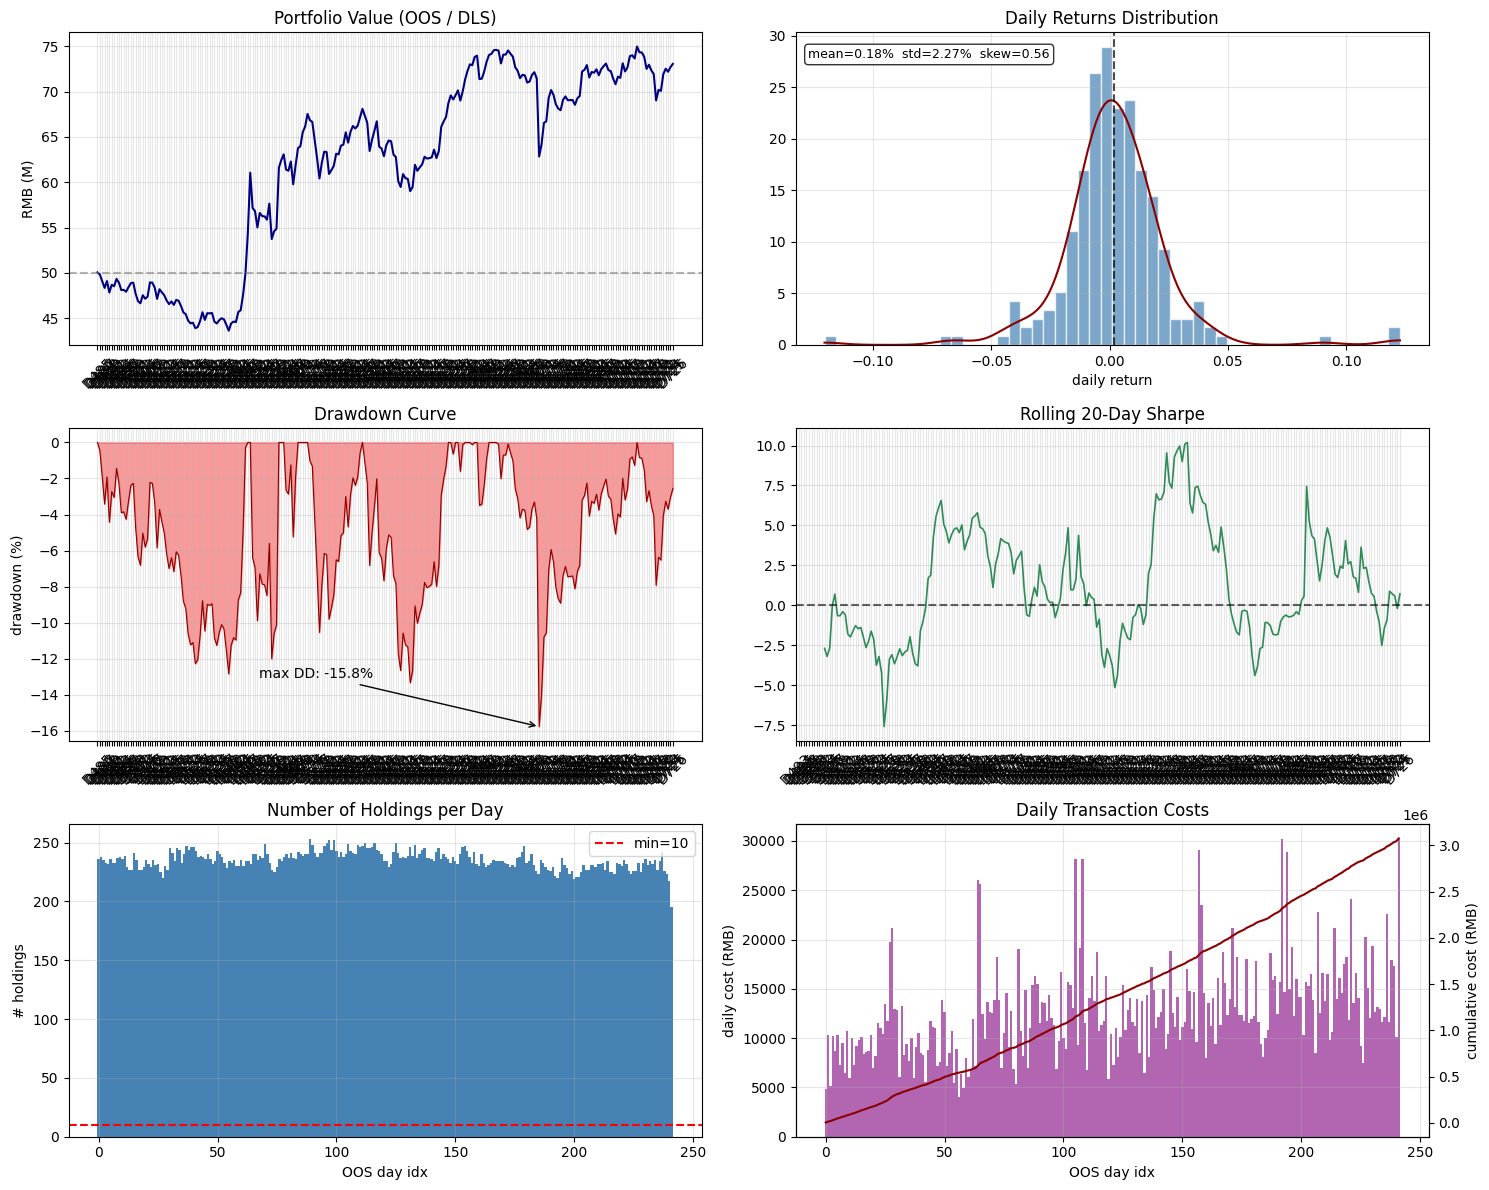

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

ax = axes[0, 0]
ax.plot(daily_df.index, daily_df["portfolio_value"] / 1e6, color="navy", lw=1.5)
ax.axhline(CONFIG["initial_capital"] / 1e6, color="gray", ls="--", alpha=0.6)
ax.set_title("Portfolio Value (OOS / DLS)")
ax.set_ylabel("RMB (M)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

ax = axes[0, 1]
r = metrics["daily_returns"]
ax.hist(r, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white")
if len(r) > 1:
    kx = np.linspace(r.min(), r.max(), 200)
    ax.plot(kx, stats.gaussian_kde(r)(kx), color="darkred", lw=1.5)
ax.axvline(r.mean(), color="black", ls="--", alpha=0.7)
ax.set_title("Daily Returns Distribution")
ax.set_xlabel("daily return")
ax.text(0.02, 0.95,
        f"mean={r.mean()*100:.2f}%  std={r.std()*100:.2f}%  skew={r.skew():.2f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.grid(alpha=0.3)

ax = axes[1, 0]
dd = metrics["drawdowns"].copy()
# Remove the synthetic initial-capital point from date-string plots.
dd = dd[dd.index != "__INITIAL_CAPITAL__"] * -100
ax.fill_between(dd.index, dd, 0, color="red", alpha=0.4)
ax.plot(dd.index, dd, color="darkred", lw=0.8)
mdd_day = dd.idxmin()
ax.annotate(f"max DD: {dd.min():.1f}%",
            xy=(mdd_day, dd.min()),
            xytext=(0.3, 0.2), textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Drawdown Curve")
ax.set_ylabel("drawdown (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

ax = axes[1, 1]
r_idx = metrics["daily_returns"].copy()
# daily_returns may include the synthetic initial-capital → first-test-day return.
# Align it safely to daily_df for rolling plots.
if len(r_idx) == len(daily_df):
    r_idx.index = daily_df.index
elif len(r_idx) == len(daily_df) - 1:
    r_idx.index = daily_df.index[1:]
else:
    n_align = min(len(r_idx), len(daily_df))
    r_idx = pd.Series(r_idx.values[-n_align:], index=daily_df.index[-n_align:])
roll = r_idx.rolling(20)
rs   = (roll.mean() / (roll.std() + 1e-12)) * np.sqrt(CONFIG["trading_days_year"])
ax.plot(rs.index, rs, color="seagreen", lw=1.2)
ax.axhline(0, color="black", ls="--", alpha=0.6)
ax.set_title("Rolling 20-Day Sharpe")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

ax = axes[2, 0]
colors = ["red" if h < CONFIG["min_holdings"] else "steelblue"
          for h in daily_df["num_holdings"]]
ax.bar(range(len(daily_df)), daily_df["num_holdings"], color=colors, width=1.0)
ax.axhline(CONFIG["min_holdings"], color="red", ls="--", lw=1.5,
           label=f"min={CONFIG['min_holdings']}")
ax.set_title("Number of Holdings per Day")
ax.set_xlabel("OOS day idx")
ax.set_ylabel("# holdings")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2, 1]
ax.bar(range(len(daily_df)), daily_df["total_costs"], color="purple",
       width=1.0, alpha=0.6, label="daily")
ax.set_xlabel("OOS day idx")
ax.set_ylabel("daily cost (RMB)")
ax2 = ax.twinx()
ax2.plot(range(len(daily_df)), daily_df["total_costs"].cumsum(),
         color="darkred", lw=1.5, label="cumulative")
ax2.set_ylabel("cumulative cost (RMB)")
ax.set_title("Daily Transaction Costs")
ax.grid(alpha=0.3)

plt.tight_layout()
out_png = PROJECT_ROOT / "outputs" / "backtest_report_shifu_dls_shifted_tplus2_conf_filter.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
print(f"saved → {out_png}")
plt.show()


DLS W_t distribution summary
non-zero weights: 48890
positive weights: 48890
negative weights: 0 (expected 0 in this long-only version)
count    48890.000000
mean         0.004683
std          0.010766
min          0.000488
1%           0.000504
5%           0.000538
25%          0.000792
50%          0.001478
75%          0.003807
95%          0.017994
99%          0.055633
max          0.175141
Name: weight, dtype: float64
saved → /kaggle/working/shifu_dls_oos/outputs/dls_weight_distribution_Wt.png


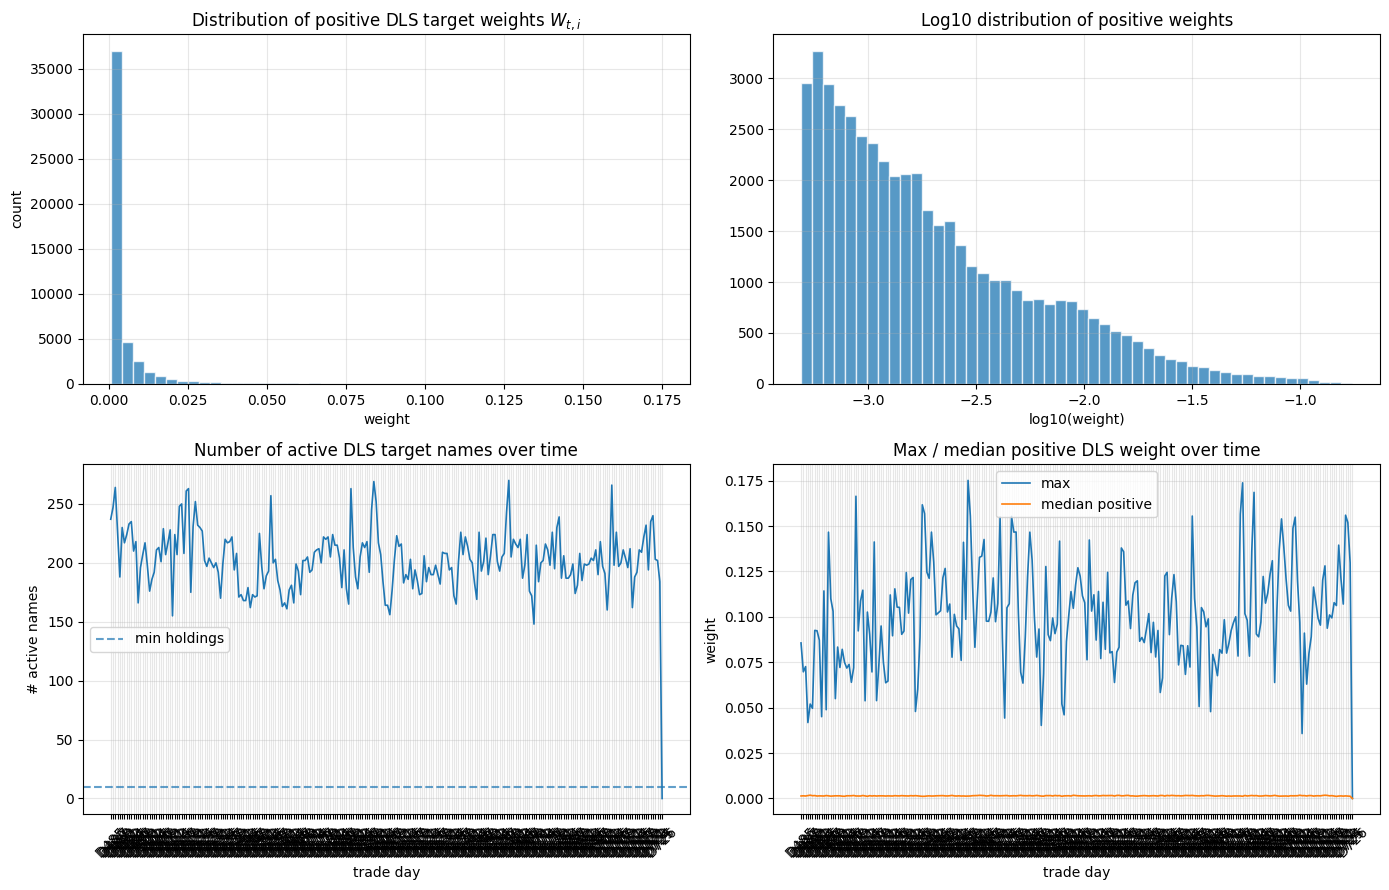

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Distribution of DLS target weights W_t
# ─────────────────────────────────────────────────────────────────────────────
if 'dls_weight_long_df' not in globals():
    dls_weight_long_df = dls_provider.weights_long_frame()

if dls_weight_long_df.empty:
    print("No non-zero DLS weights were recorded.")
else:
    w_all = dls_weight_long_df["weight"].astype(float)
    w_pos = w_all[w_all > 0]
    w_neg = w_all[w_all < 0]

    print("DLS W_t distribution summary")
    print("non-zero weights:", len(w_all))
    print("positive weights:", len(w_pos))
    print("negative weights:", len(w_neg), "(expected 0 in this long-only version)")
    print(w_all.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    ax.hist(w_pos, bins=50, alpha=0.75, edgecolor="white")
    ax.set_title("Distribution of positive DLS target weights $W_{t,i}$")
    ax.set_xlabel("weight")
    ax.set_ylabel("count")
    ax.grid(alpha=0.3)

    ax = axes[0, 1]
    if len(w_pos) > 0:
        ax.hist(np.log10(w_pos + 1e-12), bins=50, alpha=0.75, edgecolor="white")
    ax.set_title("Log10 distribution of positive weights")
    ax.set_xlabel("log10(weight)")
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    if not dls_debug_df.empty:
        ax.plot(dls_debug_df["trade_day_id"], dls_debug_df["num_target_names"], lw=1.2)
        ax.axhline(CONFIG["min_holdings"], ls="--", alpha=0.7, label="min holdings")
    ax.set_title("Number of active DLS target names over time")
    ax.set_xlabel("trade day")
    ax.set_ylabel("# active names")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    if not dls_debug_df.empty:
        ax.plot(dls_debug_df["trade_day_id"], dls_debug_df["max_weight"], lw=1.2, label="max")
        ax.plot(dls_debug_df["trade_day_id"], dls_debug_df["median_positive_weight"], lw=1.2, label="median positive")
    ax.set_title("Max / median positive DLS weight over time")
    ax.set_xlabel("trade day")
    ax.set_ylabel("weight")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    w_png = PROJECT_ROOT / "outputs" / "dls_weight_distribution_Wt.png"
    plt.savefig(w_png, dpi=150, bbox_inches="tight")
    print(f"saved → {w_png}")
    plt.show()


## 13. OOS trade log / submission CSV

In [20]:
sub_df = pm.get_submission_df()

# format & validation checks
sub_df = sub_df[["trade_day_id", "asset_id", "buy_percentage", "sell_percentage"]]
assert sub_df[["trade_day_id", "asset_id"]].duplicated().sum() == 0
assert sub_df["buy_percentage"].between(0, 1).all()
assert sub_df["sell_percentage"].between(0, 1).all()
assert not ((sub_df["buy_percentage"] == 0) & (sub_df["sell_percentage"] == 0)).any()
assert not ((sub_df["buy_percentage"] > 0) & (sub_df["sell_percentage"] > 0)).any()
for day, _ in sub_df.groupby("trade_day_id"):
    if day in daily_df.index and daily_df.loc[day, "num_holdings"] < CONFIG["min_holdings"]:
        raise AssertionError(f"day {day}: holdings < {CONFIG['min_holdings']}")
print("✅ Validation passed")

fname = PROJECT_ROOT / "submissions" / f"{CONFIG['team_id']}_oos_shifu_dls_kaggle_sell_{CONFIG['sell_mode']}.csv"
sub_df.to_csv(fname, index=False)
print(f"Trade log saved: {fname}")
print(f"Rows: {len(sub_df)}  Days: {sub_df['trade_day_id'].nunique()}  "
      f"Assets: {sub_df['asset_id'].nunique()}")


✅ Validation passed
Trade log saved: /kaggle/working/shifu_dls_oos/submissions/T001_oos_shifu_dls_kaggle_sell_open.csv
Rows: 7495  Days: 242  Assets: 459


## 14. Kaggle run notes

### Required Kaggle inputs

Use **Add Input** to attach:

```text
1) arshiaabolghasemi/feishu-dataset
   ├── daily_data_in_sample.parquet
   ├── lob_data_in_sample.parquet
   ├── daily_data_release_stage_out_of_sample.parquet
   └── lob_data_release_stage_out_of_sample.parquet

2) A public or private model dataset
   └── best_model_alpha_0015.pt
```

The dataset folder names do not need to match the examples because the setup cell recursively searches `/kaggle/input`.

### Recommended Kaggle settings

```text
Accelerator: GPU
Internet: Off is supported
Persistence: Save Version after a successful run
```

### Output locations

```text
/kaggle/working/shifu_dls_oos/outputs/
/kaggle/working/shifu_dls_oos/submissions/
/kaggle/working/shifu_dls_oos_results.zip
```

The ZIP archive is created by the final packaging cell and can be downloaded from Kaggle's **Output** panel.


## 15. Final chart-based interactive replay dashboard

This final cell is the only interactive dashboard cell in the notebook. It provides a visual replay over a selectable OOS window, including DeepLOB probabilities, DLS target weights, weight gaps, executed buys and sells, transaction costs, holdings, and the portfolio path.

In [21]:

# Final chart-based interactive replay dashboard.
# This cell is optional. Core model training, backtesting, metrics, CSV exports,
# and static charts are already complete before this point.

DASHBOARD_AVAILABLE = True
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, HTML
except Exception as exc:
    DASHBOARD_AVAILABLE = False
    print("Interactive dashboard skipped because ipywidgets is unavailable:", repr(exc))


def _copy_df_or_empty(name, columns=None):
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    return pd.DataFrame(columns=columns or [])


def _prepare_dashboard_frames():
    daily = daily_df.reset_index().copy()
    if "trade_day_id" not in daily.columns:
        daily = daily.rename(columns={daily.columns[0]: "trade_day_id"})
    daily["window_turnover"] = daily.get("buy_turnover", 0.0) + daily.get("sell_turnover", 0.0)
    daily["daily_return"] = daily["portfolio_value"].pct_change().fillna(0.0)
    daily["running_peak"] = daily["portfolio_value"].cummax()
    daily["drawdown_pct"] = 100.0 * (daily["portfolio_value"] / daily["running_peak"] - 1.0)
    daily["total_costs"] = daily.get("total_costs", 0.0)

    trades = _copy_df_or_empty("trade_audit_df")
    weights = _copy_df_or_empty("weight_step_audit_df")
    holdings = _copy_df_or_empty("holding_snapshot_audit_df")
    debug = _copy_df_or_empty("dls_debug_df")

    if trades.empty and hasattr(pm, "get_trade_audit_df"):
        trades = pm.get_trade_audit_df()
    if weights.empty and hasattr(pm, "get_weight_step_audit_df"):
        weights = pm.get_weight_step_audit_df()
    if holdings.empty and hasattr(pm, "get_holding_snapshot_audit_df"):
        holdings = pm.get_holding_snapshot_audit_df()
    if debug.empty and hasattr(dls_provider, "debug_frame"):
        debug = dls_provider.debug_frame()

    return daily, trades, weights, holdings, debug


def _fmt_money(x):
    try:
        return f"RMB {float(x):,.0f}"
    except Exception:
        return ""


def _fmt_pct_decimal(x):
    try:
        return f"{100.0 * float(x):.2f}%"
    except Exception:
        return ""


def _short_asset_label(asset_id, max_len=18):
    text = str(asset_id)
    return text if len(text) <= max_len else text[:max_len - 1] + "…"


def _top_abs(df, column, n):
    if df.empty or column not in df.columns:
        return df.copy()
    out = df.copy()
    out[column] = pd.to_numeric(out[column], errors="coerce")
    return out.reindex(out[column].abs().sort_values(ascending=False).head(int(n)).index)


def _add_value_labels(ax, values, fmt_func=None, x_offset_ratio=0.01):
    if len(values) == 0:
        return
    finite = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if finite.size == 0:
        return
    span = max(float(np.nanmax(np.abs(finite))), 1e-12)
    offset = span * x_offset_ratio
    for patch, value in zip(ax.patches, values):
        if not np.isfinite(value):
            continue
        label = fmt_func(value) if fmt_func else f"{value:.4g}"
        x = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ha = "left" if x >= 0 else "right"
        ax.text(x + (offset if x >= 0 else -offset), y, label, va="center", ha=ha, fontsize=8)


def _barh(ax, df, y_col, x_col, title, xlabel, top_n=20, value_fmt=None, center_zero=False):
    ax.clear()
    if df.empty or y_col not in df.columns or x_col not in df.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    plot_df = df.copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col]).head(int(top_n)).iloc[::-1]
    labels = [_short_asset_label(x) for x in plot_df[y_col].astype(str)]
    values = plot_df[x_col].astype(float).to_numpy()
    ax.barh(labels, values)
    if center_zero:
        ax.axvline(0.0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)
    _add_value_labels(ax, values, value_fmt)


def _plot_window_overview(axs, daily_window):
    x = np.arange(len(daily_window))
    labels = daily_window["trade_day_id"].astype(str).to_numpy()
    tick_idx = np.linspace(0, max(len(x) - 1, 0), num=min(8, len(x)), dtype=int) if len(x) else []

    axs[0].plot(x, daily_window["portfolio_value"] / 1e6)
    axs[0].set_title("Portfolio value")
    axs[0].set_ylabel("RMB millions")
    axs[0].grid(alpha=0.25)

    axs[1].plot(x, daily_window["drawdown_pct"])
    axs[1].axhline(0.0, linewidth=1)
    axs[1].set_title("Drawdown")
    axs[1].set_ylabel("Percent")
    axs[1].grid(alpha=0.25)

    axs[2].bar(x, daily_window["window_turnover"] / 1e6)
    axs[2].set_title("Daily turnover")
    axs[2].set_ylabel("RMB millions")
    axs[2].grid(axis="y", alpha=0.25)

    axs[3].bar(x, daily_window["total_costs"] / 1e3)
    axs[3].set_title("Daily transaction costs")
    axs[3].set_ylabel("RMB thousands")
    axs[3].grid(axis="y", alpha=0.25)

    axs[4].plot(x, daily_window["num_holdings"])
    axs[4].set_title("Number of holdings")
    axs[4].set_ylabel("Count")
    axs[4].grid(alpha=0.25)

    if "dls_target_names" in daily_window.columns:
        axs[5].plot(x, daily_window["dls_target_names"])
        axs[5].set_title("DLS target names")
        axs[5].set_ylabel("Count")
        axs[5].grid(alpha=0.25)
    else:
        axs[5].axis("off")

    for ax in axs:
        if len(x):
            ax.set_xticks(tick_idx)
            ax.set_xticklabels(labels[tick_idx], rotation=45, ha="right")


def _plot_weight_transition(ax, day_weights, top_n):
    ax.clear()
    if day_weights.empty:
        ax.set_title("Pre-trade, target, and post-trade weights")
        ax.text(0.5, 0.5, "No weight-audit data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    cols = ["pre_trade_weight", "target_weight", "post_trade_weight"]
    available_cols = [c for c in cols if c in day_weights.columns]
    if not available_cols:
        ax.set_title("Pre-trade, target, and post-trade weights")
        ax.text(0.5, 0.5, "Required weight columns are missing", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    plot_df = day_weights.copy()
    for c in available_cols:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce").fillna(0.0)
    plot_df["rank_abs"] = plot_df[available_cols].abs().max(axis=1)
    plot_df = plot_df.sort_values("rank_abs", ascending=False).head(int(top_n)).iloc[::-1]
    y = np.arange(len(plot_df))
    h = 0.24
    labels = [_short_asset_label(x) for x in plot_df["asset_id"].astype(str)]
    for offset, col, label in [(-h, "pre_trade_weight", "Pre-trade"), (0, "target_weight", "Target"), (h, "post_trade_weight", "Post-trade")]:
        if col in plot_df.columns:
            ax.barh(y + offset, 100.0 * plot_df[col].astype(float), height=h, label=label)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Weight (%)")
    ax.set_title("Pre-trade, target, and post-trade weights")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.25)


def _plot_executed_trade_flow(ax, day_trades, top_n):
    ax.clear()
    if day_trades.empty:
        ax.set_title("Executed buy/sell turnover")
        ax.text(0.5, 0.5, "No executed trades", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    plot_df = day_trades.copy()
    plot_df["turnover"] = pd.to_numeric(plot_df.get("turnover", 0.0), errors="coerce").fillna(0.0)
    plot_df["signed_turnover"] = np.where(plot_df.get("side", "") == "sell", -plot_df["turnover"], plot_df["turnover"])
    plot_df = plot_df.reindex(plot_df["signed_turnover"].abs().sort_values(ascending=False).head(int(top_n)).index).iloc[::-1]
    labels = [_short_asset_label(x) for x in plot_df["asset_id"].astype(str)]
    values = plot_df["signed_turnover"].astype(float).to_numpy() / 1e6
    ax.barh(labels, values)
    ax.axvline(0.0, linewidth=1)
    ax.set_title("Executed buy/sell turnover")
    ax.set_xlabel("RMB millions; buys positive, sells negative")
    ax.grid(axis="x", alpha=0.25)
    _add_value_labels(ax, values, lambda v: f"{v:+.2f}M")


def _plot_holding_composition(ax, holdings_window, top_n):
    ax.clear()
    if holdings_window.empty or "market_value" not in holdings_window.columns:
        ax.set_title("Top holding value through selected window")
        ax.text(0.5, 0.5, "No holding data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    hw = holdings_window.copy()
    hw["market_value"] = pd.to_numeric(hw["market_value"], errors="coerce").fillna(0.0)
    top_assets = (
        hw.groupby("asset_id")["market_value"].mean()
        .sort_values(ascending=False)
        .head(int(top_n))
        .index
        .tolist()
    )
    pivot = hw[hw["asset_id"].isin(top_assets)].pivot_table(
        index="trade_day_id", columns="asset_id", values="market_value", aggfunc="sum", fill_value=0.0
    )
    if pivot.empty:
        ax.set_title("Top holding value through selected window")
        ax.text(0.5, 0.5, "No top holding data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return
    pivot = pivot.reindex(sorted(pivot.index, key=lambda x: int(str(x).lstrip("D")) if str(x).lstrip("D").isdigit() else str(x)))
    x = np.arange(len(pivot.index))
    y_stack = [pivot[c].to_numpy() / 1e6 for c in pivot.columns]
    ax.stackplot(x, *y_stack, labels=[_short_asset_label(c, 10) for c in pivot.columns])
    ax.set_title("Top holding value through selected window")
    ax.set_ylabel("RMB millions")
    ax.grid(alpha=0.25)
    tick_idx = np.linspace(0, max(len(x) - 1, 0), num=min(8, len(x)), dtype=int) if len(x) else []
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(np.asarray(pivot.index.astype(str))[tick_idx], rotation=45, ha="right")
    ax.legend(loc="upper left", fontsize=7, ncol=2)


def launch_final_visual_replay_dashboard(default_window_days=100):
    daily, trades, weights, holdings, debug = _prepare_dashboard_frames()
    if daily.empty:
        raise RuntimeError("daily_df is empty. Run the backtest cells before launching the dashboard.")

    max_window = max(1, len(daily))
    default_window_days = min(int(default_window_days), max_window)

    window_slider = widgets.IntSlider(
        value=default_window_days,
        min=1,
        max=max_window,
        step=1,
        description="Window days",
        continuous_update=False,
        layout=widgets.Layout(width="520px"),
    )
    topn_slider = widgets.IntSlider(
        value=20,
        min=5,
        max=60,
        step=5,
        description="Top N",
        continuous_update=False,
        layout=widgets.Layout(width="520px"),
    )
    traded_only_toggle = widgets.Checkbox(
        value=True,
        description="Focus on traded names",
        indent=False,
    )
    day_dropdown = widgets.Dropdown(
        options=daily["trade_day_id"].astype(str).tolist(),
        value=str(daily["trade_day_id"].iloc[-1]),
        description="Trade day",
        layout=widgets.Layout(width="320px"),
    )
    output_box = widgets.Output()

    def _sync_day_options(*_):
        n = int(window_slider.value)
        window_df = daily.tail(n)
        options = window_df["trade_day_id"].astype(str).tolist()
        current = day_dropdown.value
        day_dropdown.options = options
        if current not in options:
            day_dropdown.value = options[-1]

    def _render(*_):
        with output_box:
            clear_output(wait=True)
            n = int(window_slider.value)
            top_n = int(topn_slider.value)
            selected_day = str(day_dropdown.value)
            window_df = daily.tail(n).copy()
            window_days = set(window_df["trade_day_id"].astype(str))

            day_trades = trades[trades.get("trade_day_id", pd.Series(dtype=str)).astype(str) == selected_day].copy() if not trades.empty else pd.DataFrame()
            day_weights = weights[weights.get("trade_day_id", pd.Series(dtype=str)).astype(str) == selected_day].copy() if not weights.empty else pd.DataFrame()
            day_holdings = holdings[holdings.get("trade_day_id", pd.Series(dtype=str)).astype(str) == selected_day].copy() if not holdings.empty else pd.DataFrame()
            holdings_window = holdings[holdings.get("trade_day_id", pd.Series(dtype=str)).astype(str).isin(window_days)].copy() if not holdings.empty else pd.DataFrame()

            if bool(traded_only_toggle.value) and not day_weights.empty:
                trade_assets = set(day_trades.get("asset_id", pd.Series(dtype=str)).astype(str)) if not day_trades.empty else set()
                if trade_assets:
                    day_weights_focus = day_weights[day_weights["asset_id"].astype(str).isin(trade_assets)].copy()
                else:
                    day_weights_focus = day_weights.copy()
            else:
                day_weights_focus = day_weights.copy()

            selected_row = daily[daily["trade_day_id"].astype(str) == selected_day]
            if not selected_row.empty:
                r = selected_row.iloc[0]
                metrics_html = f"""
                <div style='font-family: sans-serif; line-height: 1.6'>
                  <b>Selected trade day:</b> {selected_day}<br>
                  <b>Portfolio value:</b> {_fmt_money(r.get('portfolio_value', np.nan))} &nbsp; | &nbsp;
                  <b>Daily return:</b> {_fmt_pct_decimal(r.get('daily_return', np.nan))} &nbsp; | &nbsp;
                  <b>Drawdown:</b> {float(r.get('drawdown_pct', np.nan)):.2f}% &nbsp; | &nbsp;
                  <b>Turnover:</b> {_fmt_money(r.get('window_turnover', np.nan))} &nbsp; | &nbsp;
                  <b>Cost:</b> {_fmt_money(r.get('total_costs', np.nan))} &nbsp; | &nbsp;
                  <b>Holdings:</b> {int(r.get('num_holdings', 0))}
                </div>
                """
                display(HTML(metrics_html))

            fig, axs = plt.subplots(3, 2, figsize=(18, 14), constrained_layout=True)
            _plot_window_overview(axs.ravel(), window_df)
            fig.suptitle(f"Portfolio path over the last {n} selected OOS days", fontsize=16)
            plt.show()

            # DeepLOB probability and DLS decision charts for the selected day.
            fig, axs = plt.subplots(3, 2, figsize=(18, 16), constrained_layout=True)
            if not day_weights.empty:
                prob_df = day_weights.sort_values("confidence", ascending=False).head(top_n)
                _barh(
                    axs[0, 0],
                    prob_df,
                    "asset_id",
                    "signal_score",
                    "DeepLOB signal score",
                    "prob_up - prob_down",
                    top_n=top_n,
                    value_fmt=lambda v: f"{v:+.3f}",
                    center_zero=True,
                )
                _barh(
                    axs[0, 1],
                    prob_df,
                    "asset_id",
                    "confidence",
                    "DeepLOB confidence",
                    "|signal_score| × (1 - prob_flat)",
                    top_n=top_n,
                    value_fmt=lambda v: f"{v:.3f}",
                )

                target_df = day_weights.sort_values("target_weight", ascending=False).head(top_n)
                _barh(
                    axs[1, 0],
                    target_df,
                    "asset_id",
                    "target_weight",
                    "DLS target weights",
                    "Target weight",
                    top_n=top_n,
                    value_fmt=lambda v: f"{100*v:.2f}%",
                )

                gap_df = _top_abs(day_weights_focus, "weight_gap_before_trade", top_n)
                _barh(
                    axs[1, 1],
                    gap_df,
                    "asset_id",
                    "weight_gap_before_trade",
                    "Weight gap before trading",
                    "target weight - pre-trade weight",
                    top_n=top_n,
                    value_fmt=lambda v: f"{100*v:+.2f}%",
                    center_zero=True,
                )

                _plot_weight_transition(axs[2, 0], day_weights_focus, top_n)
            else:
                for ax in axs.ravel()[:5]:
                    ax.text(0.5, 0.5, "No DLS weight-audit data", ha="center", va="center", transform=ax.transAxes)
                    ax.axis("off")

            _plot_executed_trade_flow(axs[2, 1], day_trades, top_n)
            fig.suptitle(f"Decision replay for {selected_day}: DeepLOB → DLS weights → trades", fontsize=16)
            plt.show()

            # End-of-day holdings and allocation composition.
            fig, axs = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
            if not day_holdings.empty:
                hdf = day_holdings.copy()
                hdf["market_value"] = pd.to_numeric(hdf["market_value"], errors="coerce").fillna(0.0)
                hdf = hdf.sort_values("market_value", ascending=False).head(top_n)
                _barh(
                    axs[0],
                    hdf,
                    "asset_id",
                    "market_value",
                    "End-of-day top holdings",
                    "Market value",
                    top_n=top_n,
                    value_fmt=lambda v: _fmt_money(v),
                )
            else:
                axs[0].text(0.5, 0.5, "No holding snapshot", ha="center", va="center", transform=axs[0].transAxes)
                axs[0].axis("off")

            _plot_holding_composition(axs[1], holdings_window, min(top_n, 15))
            fig.suptitle("Holdings and allocation composition", fontsize=16)
            plt.show()

    window_slider.observe(_sync_day_options, names="value")
    window_slider.observe(_render, names="value")
    topn_slider.observe(_render, names="value")
    traded_only_toggle.observe(_render, names="value")
    day_dropdown.observe(_render, names="value")

    controls = widgets.VBox([
        widgets.HBox([window_slider, topn_slider]),
        widgets.HBox([day_dropdown, traded_only_toggle]),
    ])
    display(controls)
    display(output_box)
    _sync_day_options()
    _render()


if DASHBOARD_AVAILABLE:
    launch_final_visual_replay_dashboard(default_window_days=100)


Output()

## 16. Package Kaggle outputs for download

This cell creates one ZIP file containing the generated `outputs` and `submissions` directories. The archive appears in Kaggle's **Output** panel after the run finishes.


In [22]:
archive_base = KAGGLE_WORKING_ROOT / "shifu_dls_oos_results"
archive_path = Path(shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=PROJECT_ROOT,
))
print(f"Kaggle output archive created: {archive_path}")
print(f"Archive size: {archive_path.stat().st_size / (1024 ** 2):.2f} MB")


Kaggle output archive created: /kaggle/working/shifu_dls_oos_results.zip
Archive size: 174.29 MB
